# Байесовский подход в анализе данных
## Задание 7

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


**Баллы за задание:**

* Задача 1 — 140 баллов.
* Задача 2 — 60 баллов.
* Задача 3 — 40 баллов.

-----------

In [65]:
# Bot check

# HW_ID: ds_bayes7
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
import torch
import torch.nn as nn

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(palette='Set2', font_scale=1.3)

from IPython.display import clear_output

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. https://chat.qwen.ai/s/18d09653-bebc-4e70-9e4a-8382d44a7221?fev=0.0.230
    - Проверка кода на синтаксические и логические ошибки и описки.
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована
...

In [2]:
import os

import numpy as np
import torch
import torchvision.datasets as dset
import torch.nn as nn
import torchvision.transforms as transforms

import pyro
import pyro.distributions as dist
import pyro.contrib.examples.util  # patches torchvision
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from sklearn.decomposition import PCA
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

import seaborn as sns
sns.set(palette='Set2', font_scale=1.3)

from IPython.display import clear_output

from scipy.special import expit
from umap.umap_ import UMAP 

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
pyro.enable_validation(True)
pyro.set_rng_seed(0)

# отключим валидацию аргументов распределений
pyro.distributions.enable_validation(False)
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
USE_CUDA

True

---
### Задача 1.

<font color="red"><b>Перед выполнением задачи прочитайте советы и указания ниже.</b></font>

Эта задача призвана проиллюстрировать на простом примере принцип работы вариационного автоэнкодера (VAE) в сравнении с методом главных компонент (PCA) и простым автоэнкодером (AE) на трех наборах данных.

Реализуйте стандартную модель VAE, в котором данные как на выходе энкодера, так и на выходе декодера описываются нормальным распределением. Все слои нейронных сетей — полносвязные. Реализуйте также аналогичную модель AE.


*Указания.*
* Обязательно посмотрите код с занятия. Обращайте внимание на размерности распределений.
* Несмотря на небольшое количество данных, обучение по случайным мини-батчам может работать лучше.
* Обучайте VAE аккуратно. На таких данных он может достаточно долго пытаться приблизить данные константным средним и большой дисперсией. Спустя большое количество итераций он все же нащупает правильную зависимость. Сотни тысяч итераций по мини-батчам — нормально.
* Обучение может и не сойтись к желаемой зависимости из-за неправильного выбора гиперпараметров сети и шага обучения. Посмотрите на выбор гиперпараметров в примерах с занятий.
* Не стоит брать слишком глубокие сети для достаточно простых данных. Но и слишком маленькие тоже не стоит, 2-4 слоя должно хватать.
* Обратите внимание на функции активации. Особенно для компонент, отвечающих за дисперсию. Возможно, потребуется перебрать несколько вариантов. Не забудьте, что дисперсия не может быть отрицательной :)
* В некоторых случаях может помочь использование или неиспользование слоев Dropout и BatchNorm.
* **Если у вас получаются плохо интерпретируемые результаты, скорее всего модель обучилась неправильно, или гиперпараметры выбраны неудачно.** Перечитайте еще раз все рекомендации, перепроверьте свое решение. Если не помогло, задайте вопрос в чате.

# **КАКИХ 3 НАБОРАХ?**
## **Я ВОЗЬМУ MNIST, ТАК КАК ДАННЫЕ НЕ БЫЛИ ПРЕДОСТАВЛЕНЫ.**

In [4]:
def callback(train_elbo, test_elbo, test_epoch_num, epoch, title="ELBO"):
    '''
    Отрисовка текущего статуса обучения.    
    '''
    
    # Отложенная очистка экрана
    clear_output(wait=True)
    
    # Объявление фигуры и сетки
    plt.figure(figsize=(10, 4), constrained_layout=False)
    plt.plot(range(1, len(train_elbo)+1), train_elbo, lw=2, color='#00CC66', label='train')
    plt.plot(test_epoch_num, test_elbo, lw=2, color='#FF3300', label='test')
    plt.legend()
    plt.xlabel('Номер эпохи')
    plt.title(f'Эпоха {epoch}. {title}')
    plt.show()

def visualize_or_not(it, n_iter):
    """
    Функция, которая определяет, визуализировать ли результат данной итерации.

    * it -- номер текущей итерации
    * n_iter -- количество итераций чередования E и M шагов
    """

    return (
        (it < 10)
        or ((it % 10 == 0) and (it < 100))
        or ((it % 100 == 0) and (it < 1000))
        or (it % 1000 == 0)
    )

### **VAE**

Возьмем энкодер и декодер с занятия, упростив их до 3 слоев.

In [5]:
class Encoder(nn.Module):

    def __init__(self, y_dim, p=0.1):
        super(Encoder, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(p),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(p),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(p),
        )

        self.fc_mean = nn.Linear(128, y_dim)
        self.fc_logvar = nn.Linear(128, y_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.net(x)
        y_loc = self.fc_mean(h)
        y_scale = F.softplus(self.fc_logvar(h)) + 1e-6
        return y_loc, y_scale


class Decoder(nn.Module):
    def __init__(self, y_dim, p=0.1):
        super(Decoder, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(y_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(p),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(p),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(p),
        )

        self.fc_mean = nn.Linear(512, 28 * 28)
        self.fc_logvar = nn.Linear(512, 28 * 28)

    def forward(self, y):
        h = self.net(y)
        mean = torch.sigmoid(self.fc_mean(h))
        logvar = self.fc_logvar(h)

        scale = F.softplus(logvar).view(-1, 1, 28, 28) + 1e-6
        mean = mean.view(-1, 1, 28, 28)

        return mean, scale

In [6]:
class VAE(nn.Module):
    """Реализация модели сверточного вариационного автоэнкодера."""

    def __init__(self, y_dim=2, p=0.2, use_cuda=False):
        """
        y_dim -- размерность скрытого пространства
        p -- параметр dropout
        use_cuda -- использовать ли cuda
        """

        super().__init__()

        # Объявляем энкодер и декодер
        self.encoder_ = Encoder(y_dim, p)
        self.decoder_ = Decoder(y_dim, p)

        if use_cuda:
            self.cuda()

        self.use_cuda = use_cuda
        self.y_dim = y_dim

    def model(self, x):
        """
        Метод, определяющий совместное распределение (X, Y) с помощью
        априорного распределения Y и распределения X|Y.
        Величина X является наблюдаемой и передается как x.
        """

        if self.use_cuda:
            x = x.cuda()

        # регистрируем PyTorch-модуль в Pyro
        pyro.module("decoder", self.decoder_)

        with pyro.plate("data", x.shape[0]):
            # гиперпараметры априорного распределения
            y_loc = x.new_zeros(torch.Size((x.shape[0], self.y_dim)))
            y_scale = x.new_ones(torch.Size((x.shape[0], self.y_dim)))

            # Cемпл из априорного распределения.
            # На самом же деле при вычислении ELBO значение будет семплироваться в guide.
            y = pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))

            # Декодируем значение из скрытого пространства
            loc_img, scale_img = self.decoder_(y)
            scale_img = torch.clamp(scale_img, min=1e-3, max=1.0)

            pyro.sample(
                "obs",
                dist.Normal(loc_img, scale_img).to_event(3),
                obs=x,
            )


    def guide(self, x):
        """
        Метод, определяющий вариационное распределение Y используя при этом X.
        """

        if self.use_cuda:
            x = x.cuda()

        # регистрируем PyTorch-модуль в Pyro
        pyro.module("encoder", self.encoder_)

        with pyro.plate("data", x.shape[0]):

            # Кодируем изображение в значения из скрытого пространства
            y_loc, y_scale = self.encoder_(x)

            # Семплируем значения из скрытого пространства
            pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))

    def encoder(self, x, return_cpu=True):
        """Обертка над энкодером, выполняющая работу по переводу тензоров между CPU и GPU"""

        if self.use_cuda:
            x = x.cuda()

        y_loc, y_scale = self.encoder_(x)

        if self.use_cuda and return_cpu:
            y_loc = y_loc.cpu()
            y_scale = y_scale.cpu()
        return y_loc, y_scale

    def decoder(self, y, return_cpu=True):
        """Обертка над декодером, выполняющая работу по переводу тензоров между CPU и GPU"""

        if self.use_cuda:
            y = y.cuda()

        loc_img, scale_img = self.decoder_(y)

        if self.use_cuda and return_cpu:
            loc_img = loc_img.cpu()
            scale_img = scale_img.cpu()
        return loc_img, scale_img

    def reconstruct_img(self, x, return_cpu=True):
        """Прогоняет картинку через всю сеть и выполняет работу по переводу тензоров между CPU и GPU"""

        if self.use_cuda:
            x = x.cuda()

        # Кодируем полученные изображения, получая распределение в скрытом пространстве
        y_loc, y_scale = self.encoder_(x)
        # Cэмплируем точки в скрытом пространстве
        y = dist.Normal(y_loc, y_scale).sample()
        # Восстанавливаем соответствующее им изображение
        loc_img = self.decoder_(y)

        if self.use_cuda and return_cpu:
            loc_img = loc_img.cpu()
        return loc_img

    def init_svi(self, lr=1e-3):
        self.svi = SVI(self.model, self.guide, Adam({"lr": lr}), loss=Trace_ELBO())

    def train_epoch(self, train_loader):
        epoch_loss = 0.0
        for x, _ in train_loader:
            if self.use_cuda:
                x = x.cuda(non_blocking=True)
            epoch_loss += self.svi.step(x)
        return epoch_loss / len(train_loader.dataset)

    def evaluate_epoch(self, test_loader):
        test_loss = 0.0
        for x, _ in test_loader:
            if self.use_cuda:
                x = x.cuda(non_blocking=True)
            test_loss += self.svi.evaluate_loss(x)
        return test_loss / len(test_loader.dataset)

    def fit(self, train_loader, test_loader=None, epochs=10, lr=1e-3):
        self.init_svi(lr=lr)
        pyro.clear_param_store()

        train_elbo = []
        test_elbo = []
        test_epoch_num = []

        for epoch in tqdm(range(1, epochs + 1)):
            train_loss = self.train_epoch(train_loader)
            train_elbo.append(-train_loss)

            if test_loader is not None:
                test_loss = self.evaluate_epoch(test_loader)
                test_elbo.append(-test_loss)
                test_epoch_num.append(epoch)

            if visualize_or_not(epoch, epochs) and test_loader is not None:
                callback(train_elbo, test_elbo, test_epoch_num, epoch)

Исопльзуя этот код, легко написать класс автоэнкодера

In [7]:
class AE(nn.Module):
    def __init__(self, y_dim=2, p=0.2, use_cuda=False):
        super().__init__()

        self.encoder_ = Encoder(y_dim, p)
        self.decoder_ = Decoder(y_dim, p)

        if use_cuda:
            self.cuda()

        self.use_cuda = use_cuda
        self.y_dim = y_dim

    def forward(self, x):
        if self.use_cuda:
            x = x.cuda()

        y_loc, _ = self.encoder_(x)
        
        reconstructed, _ = self.decoder_(y_loc)
        
        return reconstructed

    def encoder(self, x, return_cpu=True):
        if self.use_cuda:
            x = x.cuda()

        y_loc, _ = self.encoder_(x)

        if self.use_cuda and return_cpu:
            y_loc = y_loc.cpu()
        return y_loc

    def decoder(self, y, return_cpu=True):
        if self.use_cuda:
            y = y.cuda()

        loc_img, scale_img = self.decoder_(y)

        if self.use_cuda and return_cpu:
            loc_img = loc_img.cpu()
            scale_img = scale_img.cpu()
        return loc_img, scale_img

    def reconstruct_img(self, x, return_cpu=True):
        if self.use_cuda:
            x = x.cuda()

        y_loc, _ = self.encoder_(x)
        loc_img = self.decoder_(y_loc)

        if self.use_cuda and return_cpu:
            loc_img = loc_img.cpu()
        return loc_img

    def train_epoch(self, train_loader, optimizer, criterion):
        self.train()
        epoch_loss = 0.0
        for x, _ in train_loader:
            if self.use_cuda:
                x = x.cuda(non_blocking=True)
            
            optimizer.zero_grad()
            
            reconstructed = self.forward(x)
            
            loss = criterion(reconstructed, x)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * x.size(0)
        
        return epoch_loss / len(train_loader.dataset)

    def evaluate_epoch(self, test_loader, criterion):
        self.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, _ in test_loader:
                if self.use_cuda:
                    x = x.cuda(non_blocking=True)
                
                reconstructed = self.forward(x)
                loss = criterion(reconstructed, x)
                test_loss += loss.item() * x.size(0)
        
        return test_loss / len(test_loader.dataset)

    def fit(self, train_loader, test_loader=None, epochs=10, lr=1e-3):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        criterion = nn.BCELoss(reduction='sum')
        
        train_losses = []
        test_losses = []
        test_epoch_num = []

        for epoch in tqdm(range(1, epochs + 1)):
            train_loss = self.train_epoch(train_loader, optimizer, criterion)
            train_losses.append(train_loss)

            if test_loader is not None:
                test_loss = self.evaluate_epoch(test_loader, criterion)
                test_losses.append(test_loss)
                test_epoch_num.append(epoch)

            if visualize_or_not(epoch, epochs) and test_loader is not None:
                callback(train_losses, test_losses, test_epoch_num, epoch, title="Loss")

        return train_losses, test_losses


In [8]:
def setup_data_loaders(batch_size=128, use_cuda=False):
    root = './data'
    download = True
    trans = transforms.ToTensor()
    
    train_set = dset.MNIST(
        root=root, train=True, transform=trans, download=download
    )
    test_set = dset.MNIST(
        root=root, train=False, transform=trans
    )

    kwargs = {'num_workers': 20, 'pin_memory': use_cuda}
    
    train_loader = torch.utils.data.DataLoader(
        dataset=train_set, batch_size=batch_size, shuffle=True, **kwargs
    )
    test_loader = torch.utils.data.DataLoader(
        dataset=test_set, batch_size=batch_size, shuffle=True, **kwargs
    )
    
    return train_loader, test_loader

train_loader, test_loader = setup_data_loaders(batch_size=256   , use_cuda=USE_CUDA)

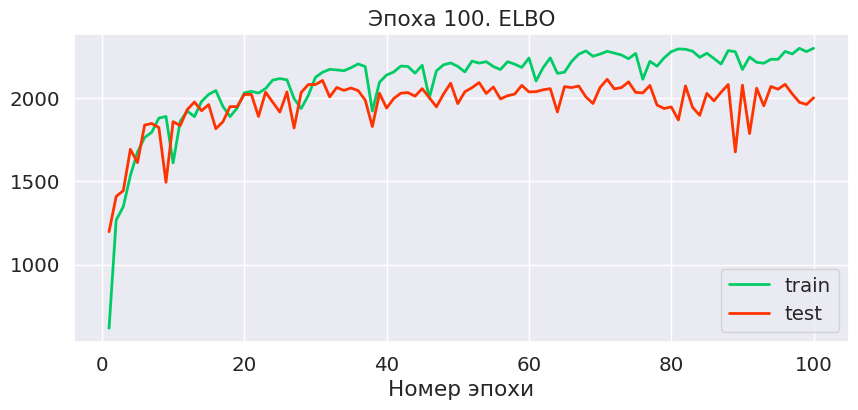

In [ ]:
vae_model = VAE(y_dim=2, p=0.1, use_cuda=USE_CUDA)
vae_model.to(DEVICE)
vae_model.fit(train_loader, test_loader, epochs=201, lr=1e-4)

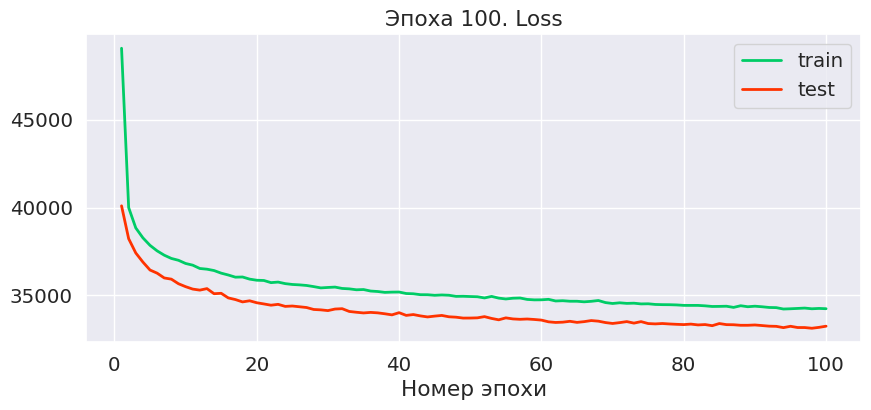

In [76]:
ae_model = AE(y_dim=2, p=0.1, use_cuda=USE_CUDA)
ae_model.to(DEVICE)
ae_model.fit(train_loader, test_loader, epochs=101, lr=5e-4);

In [77]:
X_train = train_loader.dataset.data.numpy().astype(np.float32) / 255.0
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = test_loader.dataset.data.numpy().astype(np.float32) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1)

pca = PCA(n_components=2).fit(X_train)

*Для каждого датасета далее произведите следующие сравнения.*
* Визуализируйте гистограммы значений в скрытом пространстве (на скрытом слое). *Если диапазон принимаемых значений достаточно мал, то сеть скорее всего не обучилась.*
* Возьмите сетку значений в скрытом пространстве и визуализируйте ее отображение в исходное пространство посредством декодера (в случае PCA &mdash; линейным преобразованием).
* Возьмите несколько (не более 10) равномерно удаленных точек в скрытом пространстве, с помощью декодера модели VAE получите соответствующие им распределения в исходном пространстве. Визуализируйте эти распредения с помощью эллипса. 
* Сгенерируйте выборку размера 1000 в скрытом пространстве из распределения $\mathcal{N}(0, 1)$ и визуализируйте ее отображение в исходное пространство посредством декодера (в случае PCA &mdash; линейным преобразованием). Насколько распределение ее образа похоже на распределение исходной выборки?

### 1. Визуализируйте гистограммы значений в скрытом пространстве

In [78]:
vae_values  = []
for x, _ in test_loader:
    y_loc, y_scale = vae_model.encoder(x.to("cpu"))
    tmp = np.random.normal(loc=y_loc.detach().numpy(), scale=y_scale.detach().numpy())
    vae_values.extend(tmp)
vae_values = np.array(vae_values)

In [79]:
ae_values = []

for x, _ in test_loader:

    latent_vals = ae_model.encoder(x)
    latent_vals = latent_vals.detach().cpu().numpy()
    ae_values.append(latent_vals)

ae_values = np.vstack(ae_values)


In [80]:
pca_values = pca.transform(X_test)

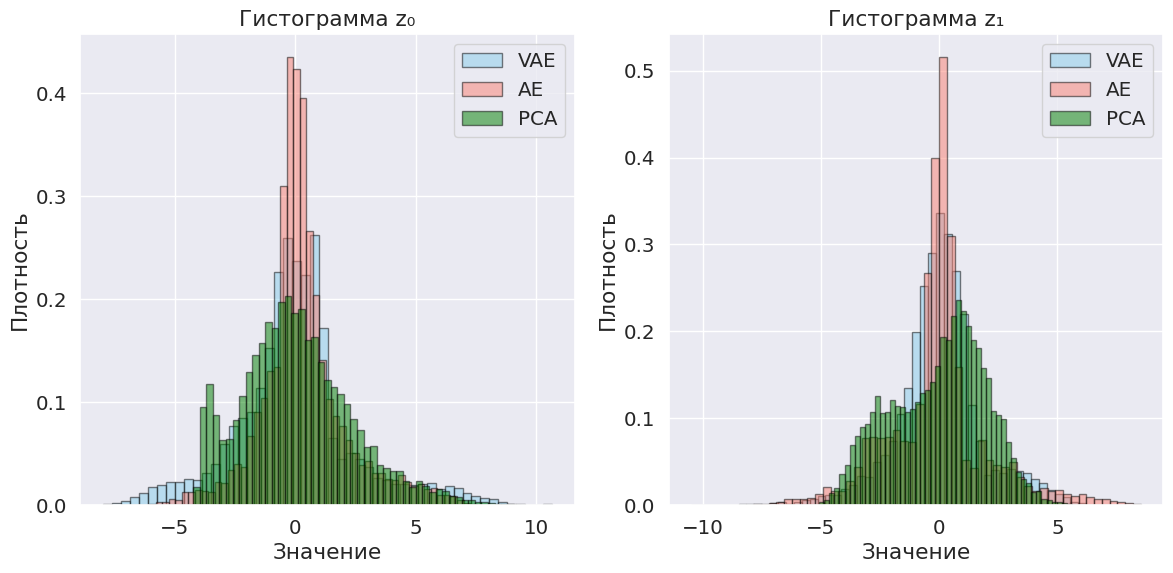

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
alpha = 0.5

# z0
axes[0].hist(vae_values[:, 0], bins=50, alpha=alpha, color='skyblue', edgecolor='black', label='VAE', density=True)
axes[0].hist(ae_values[:, 0], bins=50, alpha=alpha, color='salmon', edgecolor='black', label='AE', density=True)
axes[0].hist(pca_values[:, 0], bins=50, alpha=alpha, color='green', edgecolor='black', label='PCA', density=True)
axes[0].set_title('Гистограмма z₀')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Плотность')
axes[0].legend()

# z1
axes[1].hist(vae_values[:, 1], bins=50, alpha=alpha, color='skyblue', edgecolor='black', label='VAE', density=True)
axes[1].hist(ae_values[:, 1], bins=50, alpha=alpha, color='salmon', edgecolor='black', label='AE', density=True)
axes[1].hist(pca_values[:, 1], bins=50, alpha=alpha, color='green', edgecolor='black', label='PCA', density=True)
axes[1].set_title('Гистограмма z₁')
axes[1].set_xlabel('Значение')
axes[1].set_ylabel('Плотность')
axes[1].legend()

plt.tight_layout()
plt.show()

Как видим, компоненты стянулись к стандартному нормальному, остальные же получились более широкими.

### 2. Возьмите сетку значений в скрытом пространстве и визуализируйте ее отображение в исходное пространство посредством декодера (в случае PCA &mdash; линейным преобразованием).

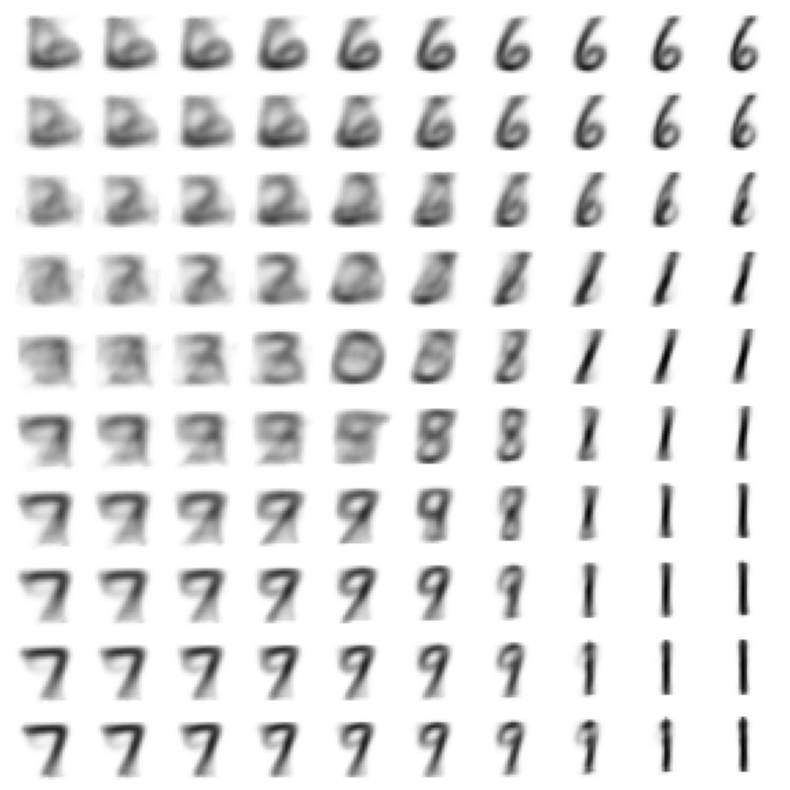

In [84]:
X1 = np.linspace(-5, 5, 10)
X2 = np.linspace(-5, 5, 10)
figure = np.zeros((28 * len(X1), 28 * len(X2)))
vae_model.eval()

with torch.no_grad():
    for i, x1 in enumerate(X1):
        for j, x2 in enumerate(X2):
            z = torch.tensor([[x1, x2]], dtype=torch.float32)
            img, _ = vae_model.decoder(z, return_cpu=True)
            digit = np.clip(img[0, 0].detach().numpy(), 0, 1)
            figure[
                (len(X1) - 1 - i) * 28 : (len(X1) - i) * 28, j * 28 : (j + 1) * 28
            ] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray_r")
plt.axis("off")
plt.show()

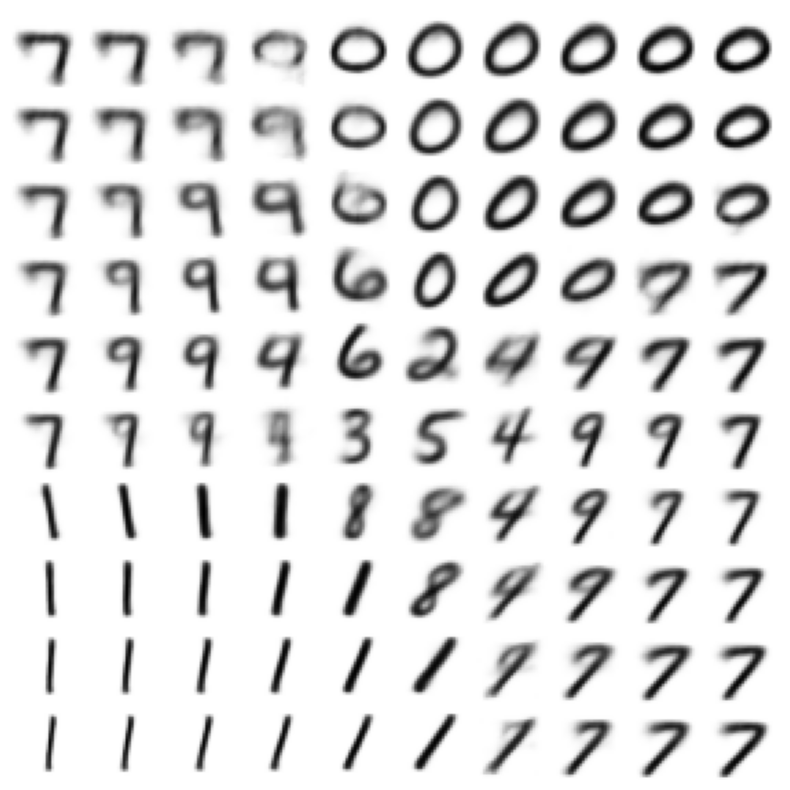

In [85]:
X1 = np.linspace(-5, 5, 10)
X2 = np.linspace(-5, 5, 10)
figure = np.zeros((28 * 10, 28 * 10))
ae_model.eval()

for i, x1 in enumerate(X1):
    for j, x2 in enumerate(X2):
        z = torch.tensor([[x1, x2]], dtype=torch.float32)
        img, _ = ae_model.decoder(z, return_cpu=True)
        img = img.detach().numpy()
        digit = img[0, 0]
        figure[i * 28: (i + 1) * 28, j * 28: (j + 1) * 28] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray_r')
plt.axis('off')
plt.show()

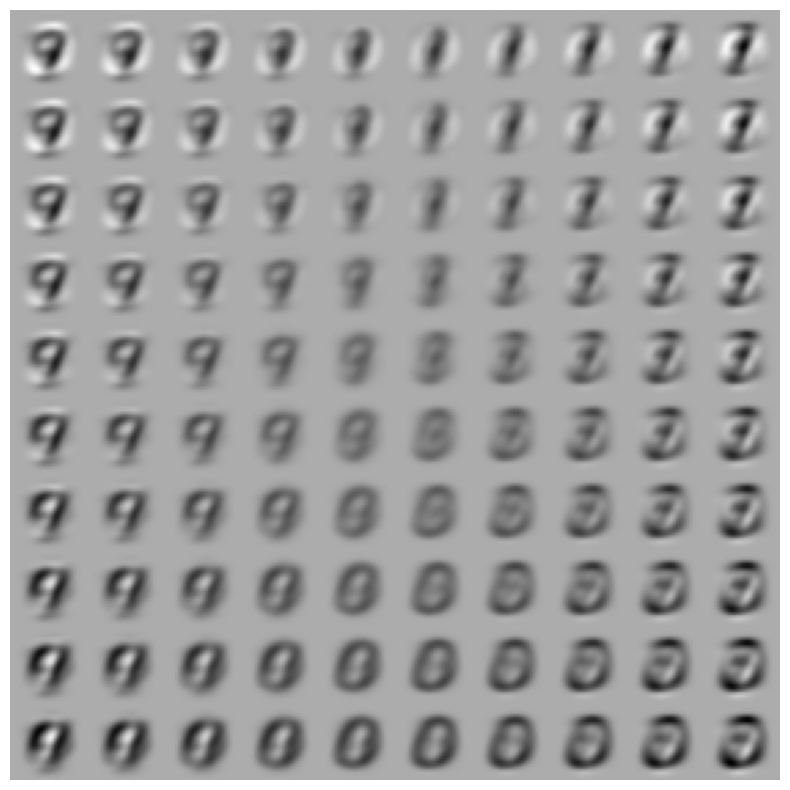

In [86]:
X1 = np.linspace(-5, 5, 10)
X2 = np.linspace(-5, 5, 10)

figure = np.zeros((28 * 10, 28 * 10))

for i, x1 in enumerate(X1):
    for j, x2 in enumerate(X2):
        z = np.array([[x1, x2]])
        img = pca.inverse_transform(z).reshape(28, 28)
        figure[i * 28: (i + 1) * 28, j * 28: (j + 1) * 28] = img

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray_r')
plt.axis('off')
plt.show()

### 4. Возьмите несколько (не более 10) равномерно удаленных точек в скрытом пространстве, с помощью декодера модели VAE получите соответствующие им распределения в исходном пространстве. Визуализируйте эти распредения с помощью эллипса.

In [113]:
coords = np.linspace(-1, 1, 5)

latent_dots = [
    torch.tensor([[x, y]], dtype=torch.float32) for x, y in zip(coords, coords)
]

latent_dots.extend([
    torch.tensor([[x, -y]], dtype=torch.float32) for x, y in zip(coords, coords)
])


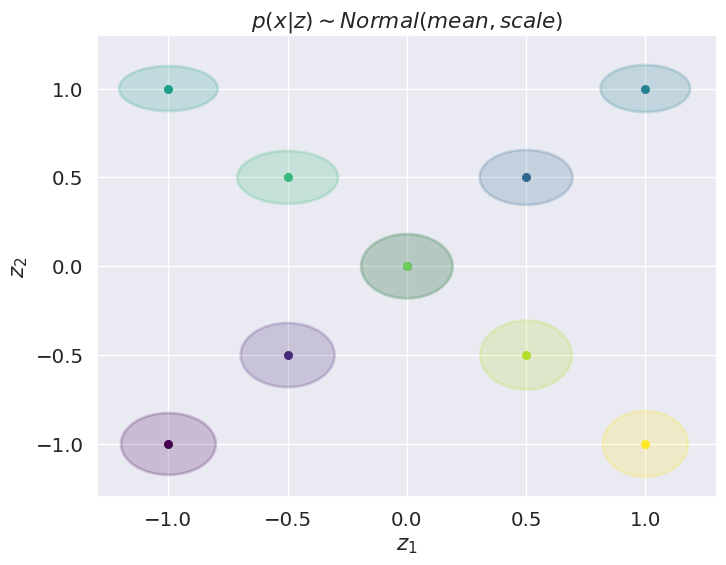

In [122]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(latent_dots)))

vae_model.eval()
with torch.no_grad():
    for dot, color in zip(latent_dots, colors):
        # mean, scale from decoder
        img_loc, img_scale = vae_model.decoder(dot, return_cpu=True)
        img_loc = img_loc.detach().numpy().reshape(28, 28)
        img_scale = img_scale.detach().numpy().reshape(28, 28)

        # усредняем по обеим координатам → один центр и радиусы
        mu_x = img_loc.mean()
        mu_y = img_loc.mean()
        sigma_x = img_scale.mean(axis=0).std()
        sigma_y = img_scale.mean(axis=1).std()

        ellipse = Ellipse(
            xy=(dot[0, 0].item(), dot[0, 1].item()),  # координаты в латентном z-пространстве
            width=3 * sigma_x,
            height=3 * sigma_y,
            edgecolor=color,
            facecolor=color,
            lw=2,
            alpha=0.2
        )
        ax.add_artist(ellipse)
        ax.scatter(*dot[0].numpy(), c=[color], s=30)

ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.set_title(r"$p(x|z) \sim Normal(mean, scale)$")
ax.grid(True)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
plt.show()


### 5. Сгенерируйте выборку размера 1000 в скрытом пространстве из распределения $\mathcal{N}(0, 1)$ и визуализируйте ее отображение в исходное пространство посредством декодера (в случае PCA &mdash; линейным преобразованием). Насколько распределение ее образа похоже на распределение исходной выборки?

In [5]:
colors = dict(zip(
    range(10), sns.color_palette('Set1', n_colors=10)
))

def colouration(gray_img, label):
    '''
    Преобразование картинки класса label из оттенков серого в цветную картинку.
    '''
    
    # Инвертируем яркость и добавляем прозрачность
    img = np.array([1-gray_img, 1-gray_img, 1-gray_img, 1-gray_img])
    
    # Задаем цвет
    for i in range(3):
        img[i] *= colors[label][i]
        
    return img.transpose((1, 2, 0))

def create_data_image(
    vae,
    data_loader=None,
    sample=None,
    labels=None,
    is_pca=False,
    pca_model=None,
    ymin=-4,
    ymax=4,
    do_expit=False,
    max_pictures=None,
    figsize=(20, 20),
    zoom=0.6,
    fname=None,
    dpi=200,
    axis=False,
    xlabel='',
    ylabel='',
    title="VAE"
):
    '''
    Отображение либо:
     • картинок из данных (data_loader),
     • либо точек из произвольной выборки (sample) в скрытом пространстве.
    Параметры:
      vae / pca_model — модель для получения обратного отображения
      is_pca — если True, используется inverse_transform(pca_model)
      sample — (N, 2) массив точек z
      labels — метки для выборки (если есть)
      остальные параметры — как в исходной функции
    '''
    with sns.axes_style('whitegrid' if axis else 'white'):
        fig, ax = plt.subplots(figsize=figsize)
        n_pictures = 0

        if sample is not None:
            # Используем заранее заданные координаты z
            z_points = sample
            if isinstance(z_points, torch.Tensor):
                z_points = z_points.cpu().numpy()
            n_points = len(z_points)
            if labels is None:
                labels = np.zeros(n_points, dtype=int)
        else:
            # Собираем точки из DataLoader как раньше
            z_points = []
            labels = []
            for batch, (x, l) in enumerate(data_loader):
                if (max_pictures is not None) and (len(x) > max_pictures - n_pictures):
                    x = x[:max_pictures - n_pictures]
                y = vae.encoder(x)[0].detach().numpy()
                if do_expit:
                    y = expit(y)
                z_points.append(y)
                labels.extend(l.cpu().numpy())
                n_pictures += len(x)
                if (max_pictures is not None) and (n_pictures >= max_pictures):
                    break
            z_points = np.concatenate(z_points, axis=0)
            labels = np.array(labels)

        # Основной цикл визуализации
        colorset = sns.color_palette('Set1', n_colors=len(np.unique(labels)))
        color_map = dict(zip(np.unique(labels), colorset))

        for i, (z, label) in enumerate(zip(z_points, labels)):
            # Ограничиваем количество картинок
            if (max_pictures is not None) and (i >= max_pictures):
                break

            if is_pca and pca_model is not None:
                # Используем обратное преобразование PCA
                recon = pca_model.inverse_transform(z.reshape(1, -1))
                recon = recon.reshape(28, 28)
            else:
                # Используем декодер VAE
                z_t = torch.tensor(z, dtype=torch.float32).unsqueeze(0)
                with torch.no_grad():
                    mean_img, _ = vae.decoder(z_t, return_cpu=True)
                recon = mean_img[0, 0].numpy()

            # Цвет и прозрачность зависят от класса
            color = color_map.get(label, (0.5, 0.5, 0.5))
            img = np.array([1 - recon, 1 - recon, 1 - recon, 1 - recon])
            for c in range(3):
                img[c] *= color[c]
            img = img.transpose(1, 2, 0)

            # Создаём объект рисунка
            imagebox = OffsetImage(img, zoom=zoom)
            ab = AnnotationBbox(imagebox, (z[0], z[1]), frameon=False)
            ax.add_artist(ab)

        # Настройки осей
        ax.set_xlim((ymin, ymax))
        ax.set_ylim((ymin, ymax))
        if not axis:
            plt.axis('off')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        plt.tight_layout()
        if fname is not None:
            plt.savefig(fname, dpi=dpi)
        ax.set_title(title, fontsize=40)
        plt.show()

In [160]:
sample = np.random.multivariate_normal(mean = (0, 0), cov = np.eye(2), size=1000)

Нарисуем распределение нашей выборки

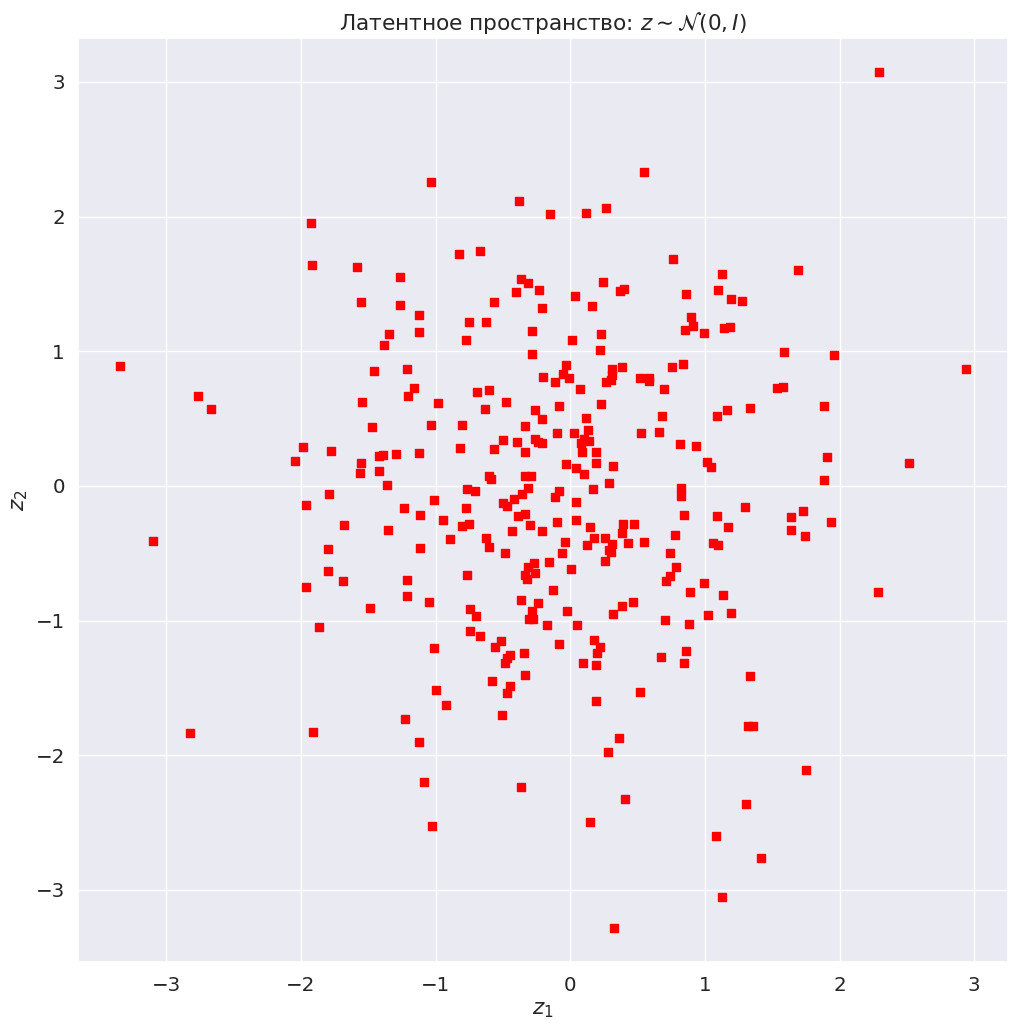

In [171]:
plt.figure(figsize=(12,12))
plt.scatter(sample[:300, 0], sample[:300, 1], marker="s", color="red")
plt.title("Латентное пространство: $z \\sim \\mathcal{N}(0, I)$")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.axis('equal')
plt.grid(True)
plt.show()

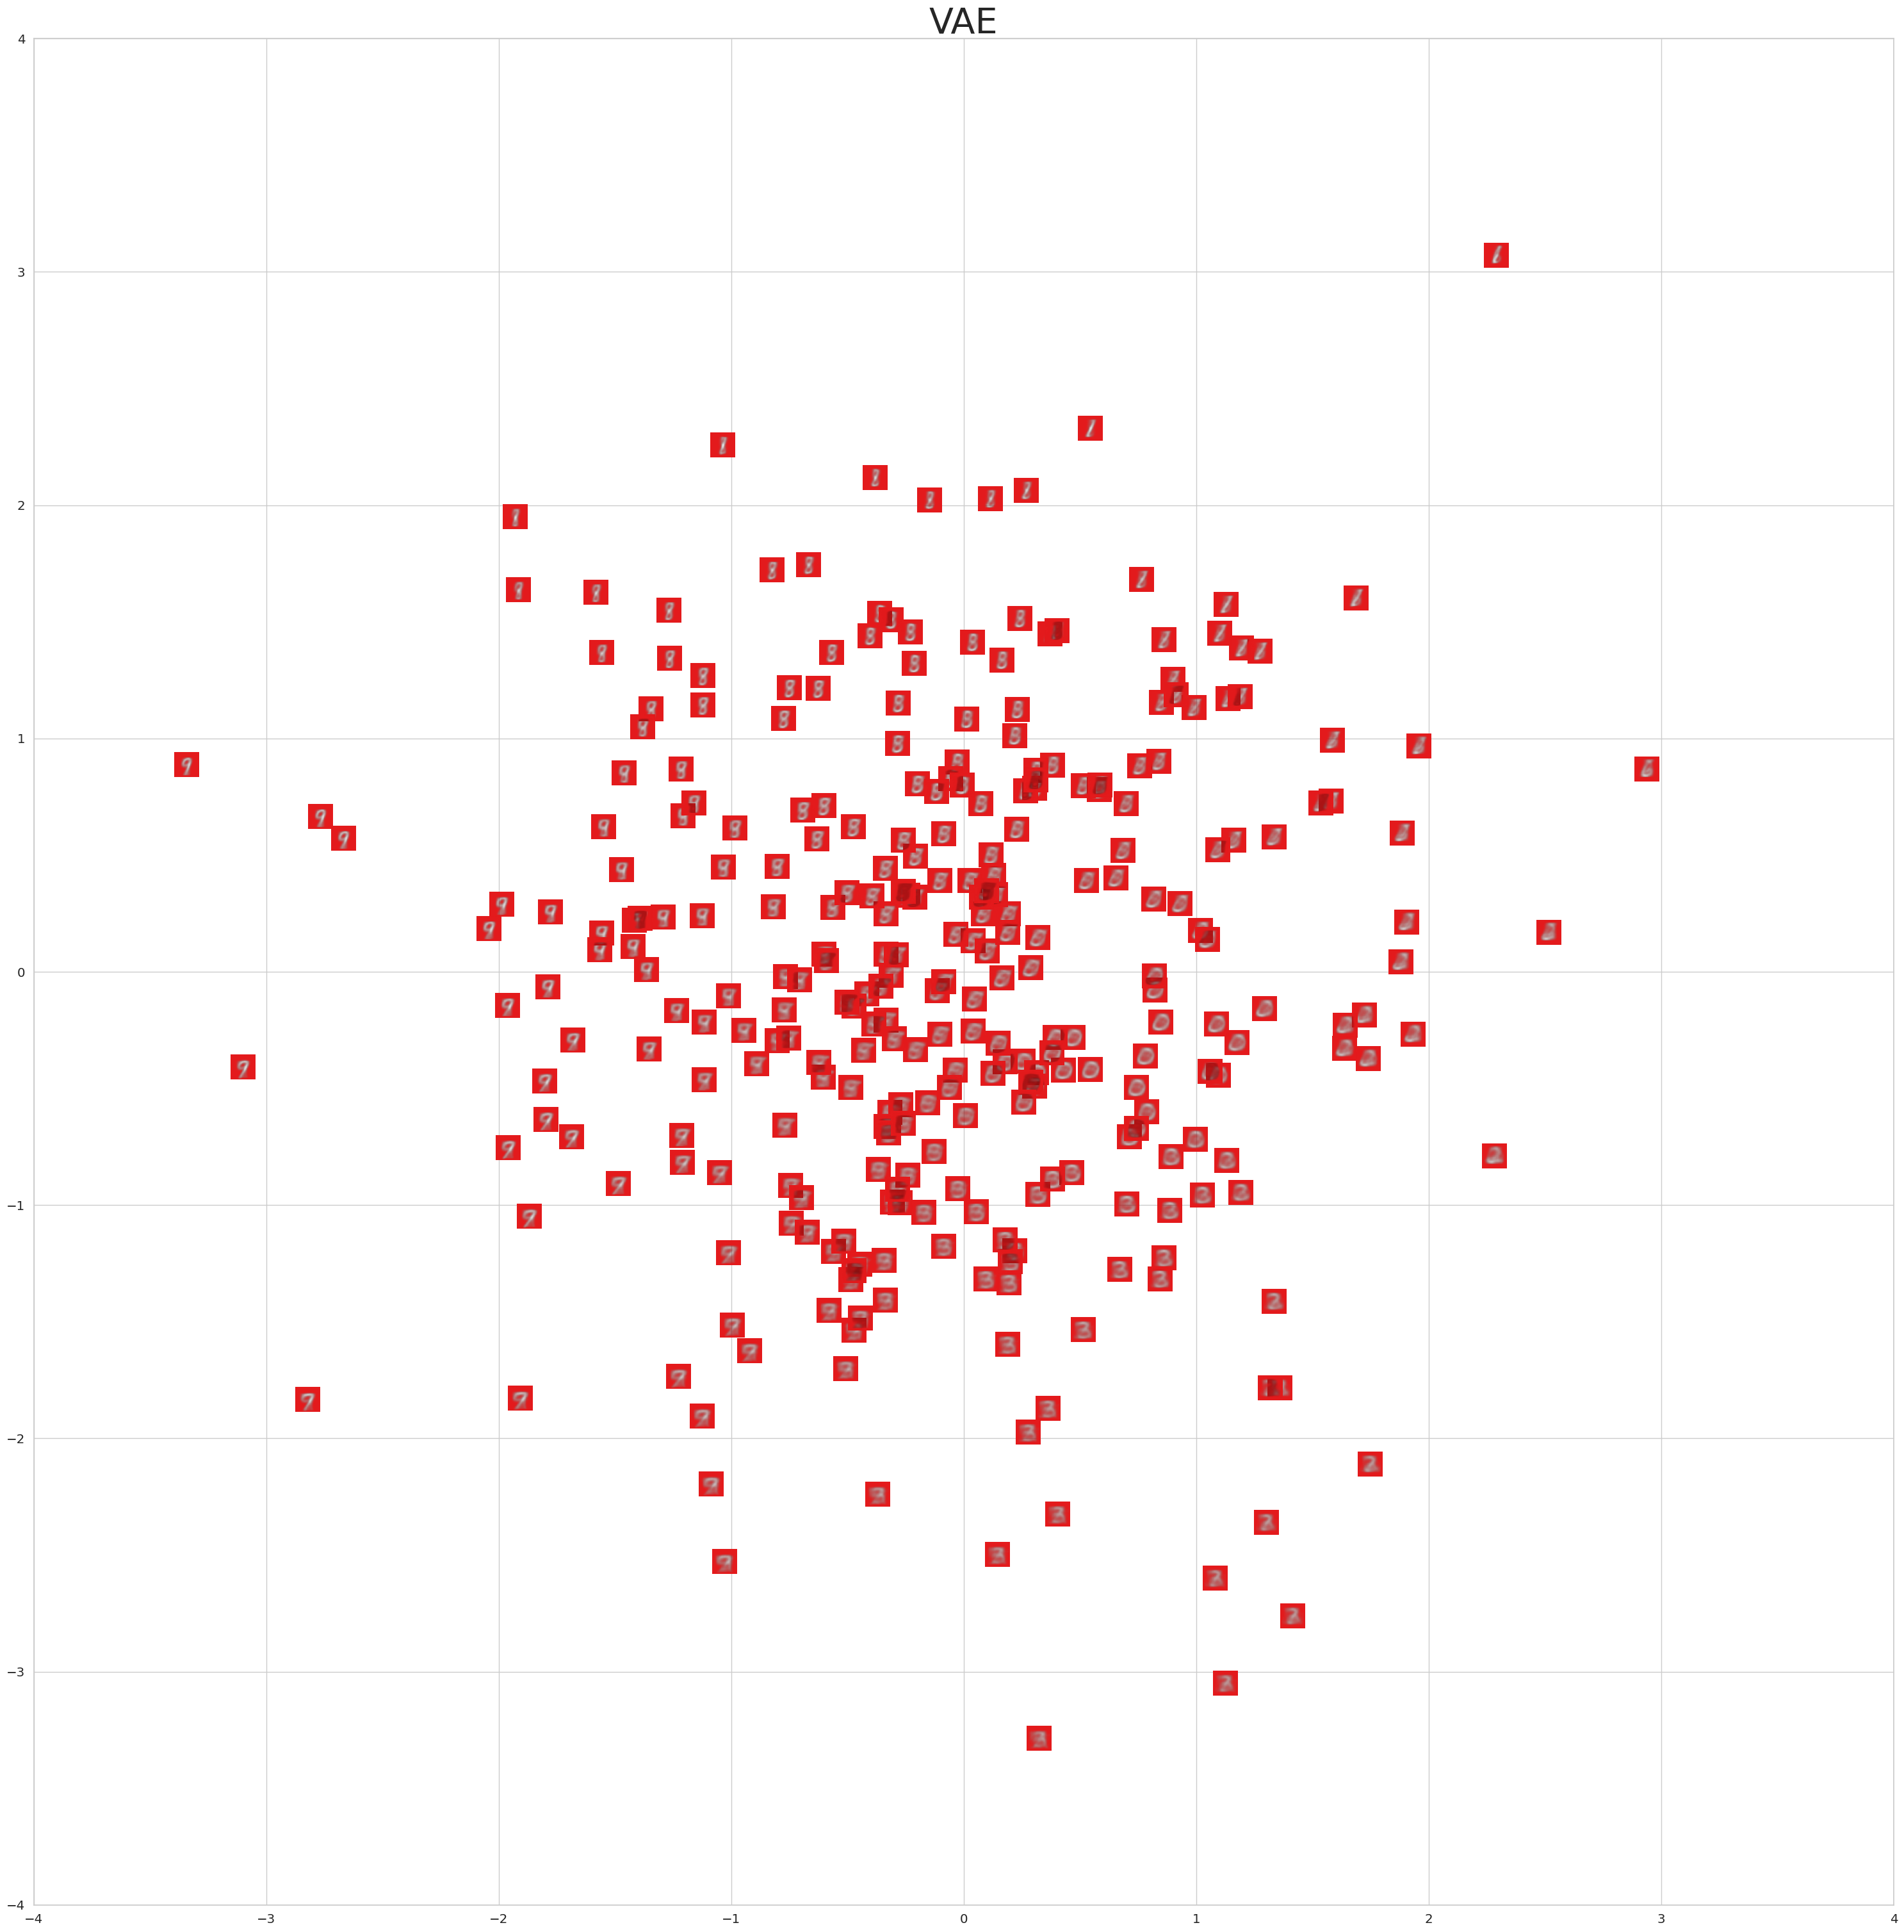

In [166]:
create_data_image(vae_model, sample=sample, max_pictures=300, figsize=(30, 30), zoom=1, axis=True)

Как видим, декодер VAE правильно повторил стркутуру латентного пространства 

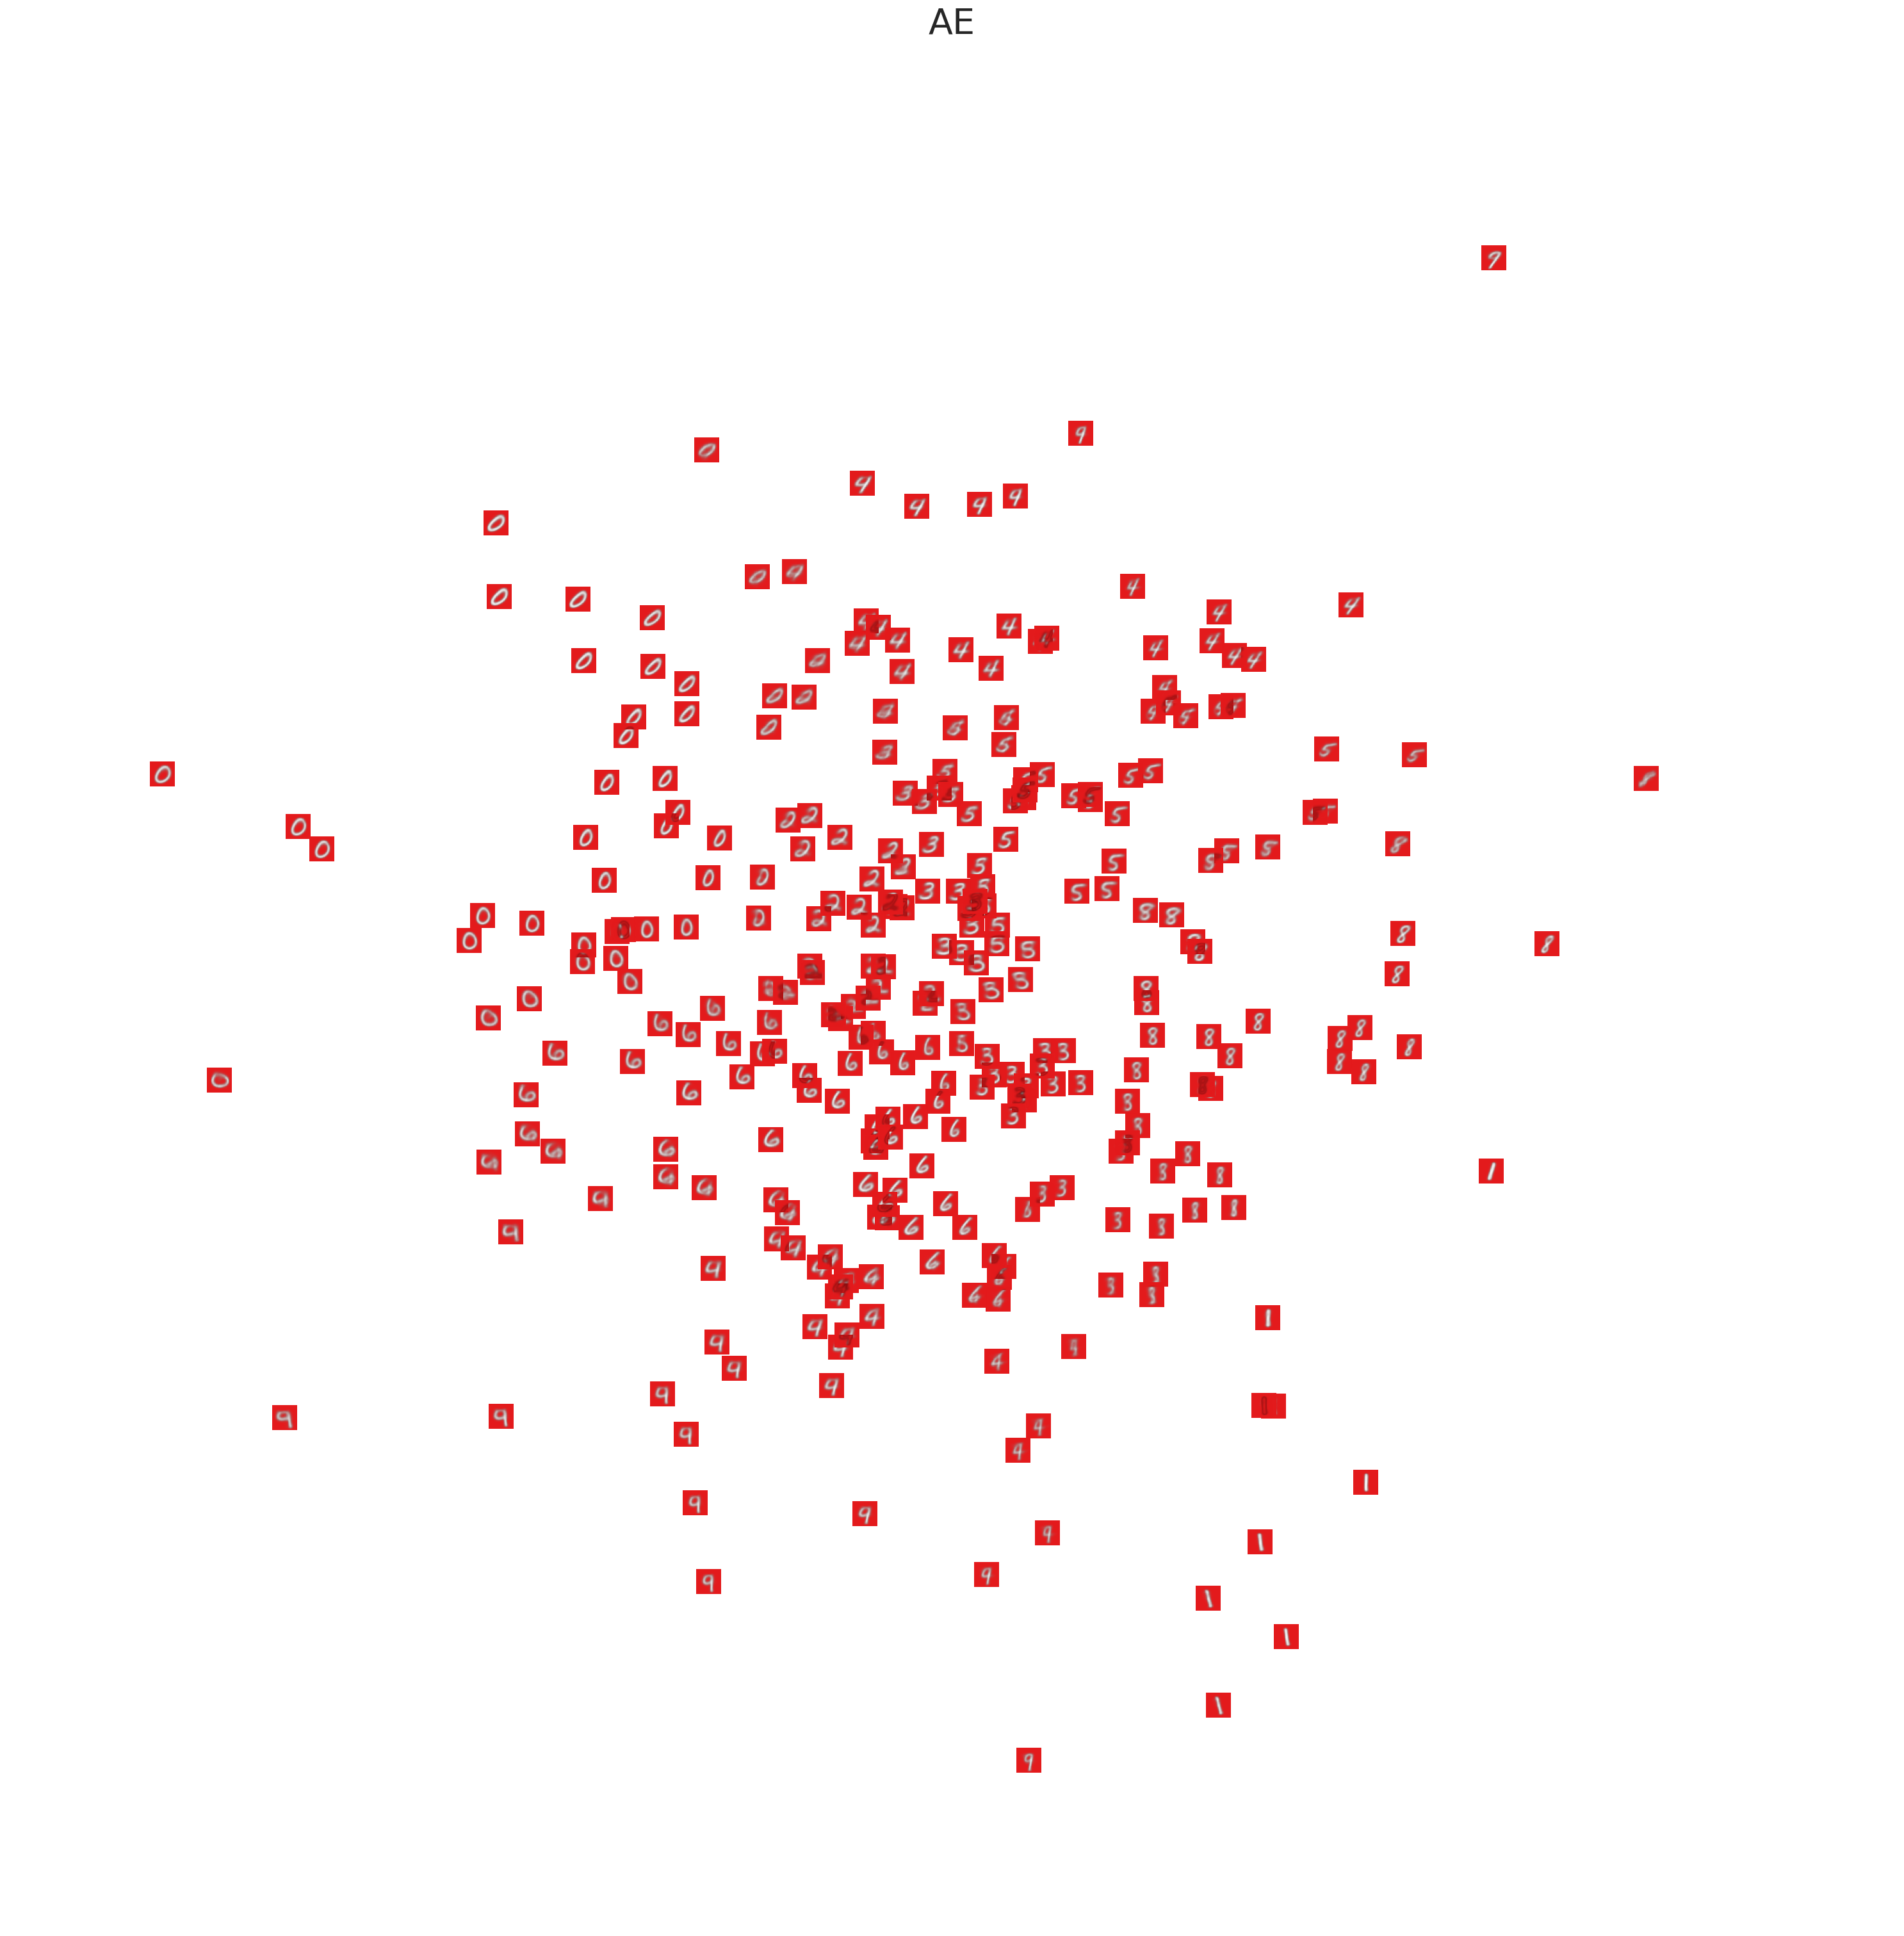

In [162]:
create_data_image(ae_model, sample=sample, title="AE", max_pictures=300, figsize=(30, 30), zoom=1)

Как видим, декодер AE правильно повторил стркутуру латентного пространства 

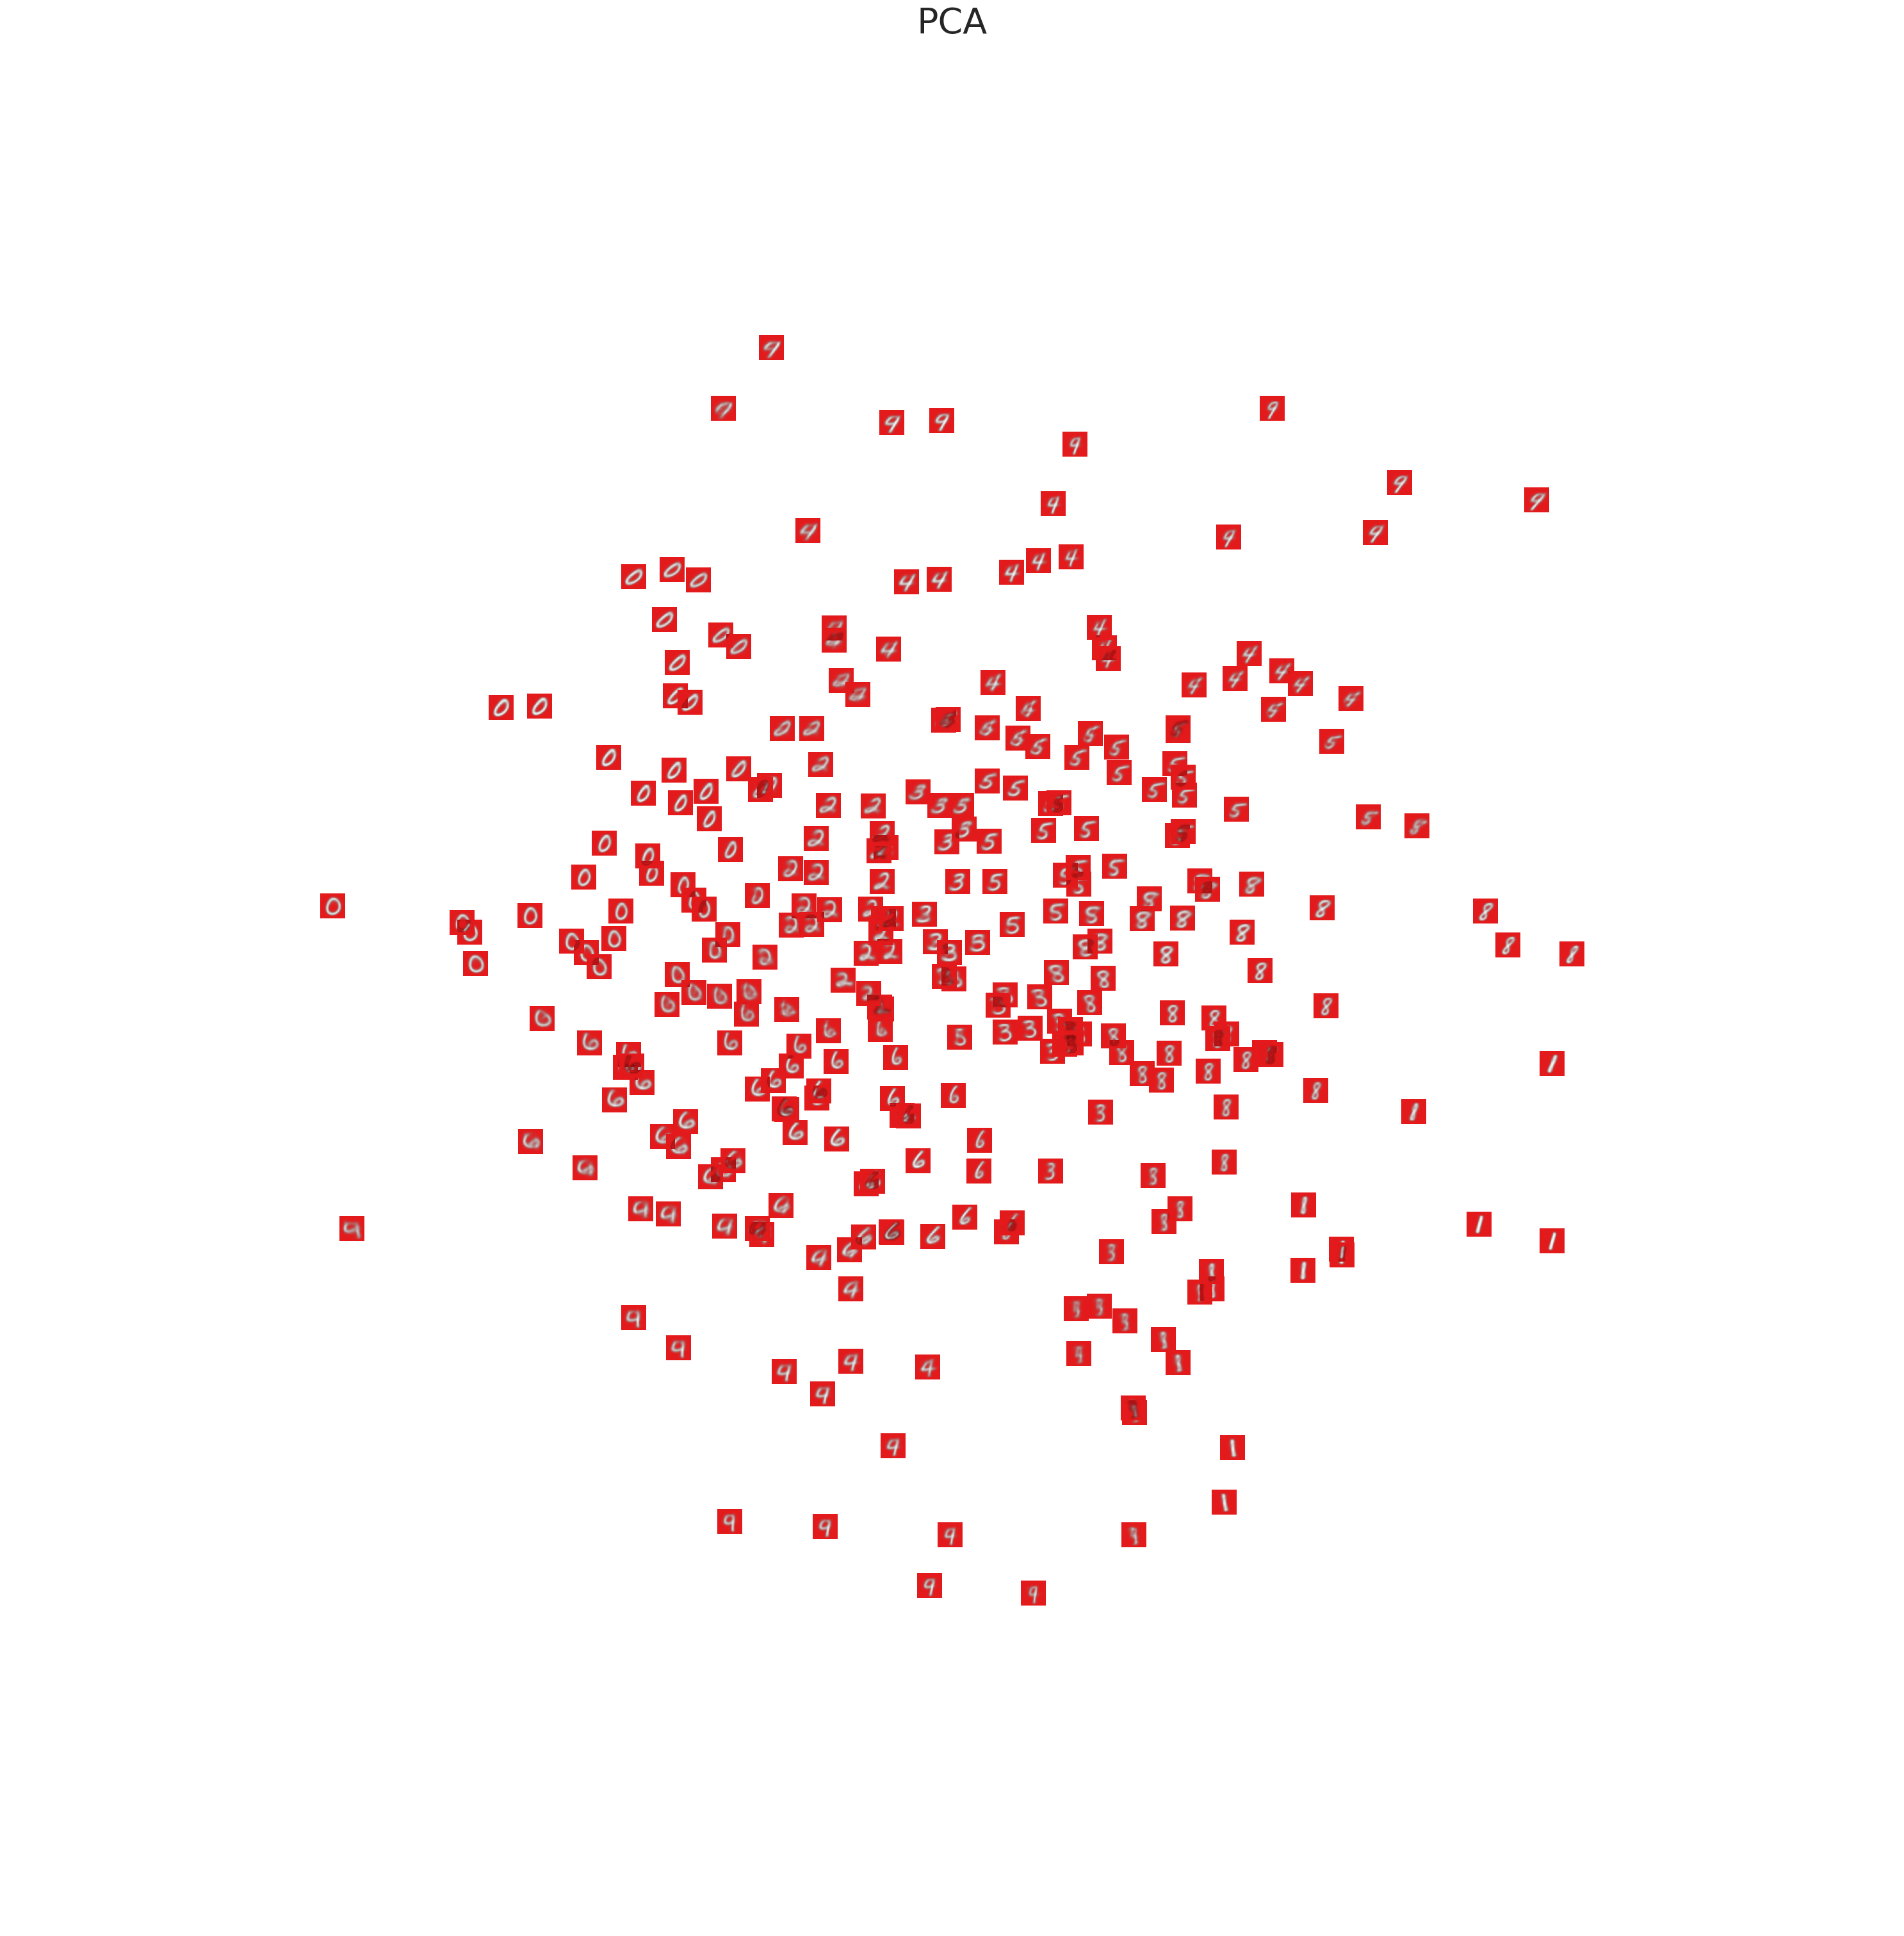

In [158]:
create_data_image(ae_model, sample=sample, is_pca=True, title="PCA", max_pictures=300, figsize=(30, 30), zoom=1)

Видим, что то что отображает PCA отличается от исходного распределения выборки.

**1.** Рассмотрите те данные, с которыми вы работали в предыдущем домашнем задании про вероятностый PCA. Обучите на этих данных VAE и сравните с вероятностным PCA.

In [17]:
np.random.seed(42)
torch.manual_seed(42)

mu = torch.tensor([2.0, -1.0])
Sigma = torch.tensor([[4.0, 3.5],
                      [3.5, 4.0]])

train_dist = torch.distributions.MultivariateNormal(mu, covariance_matrix=Sigma)
train_data = train_dist.sample((500,))
valid_data = train_dist.sample((500,))

mu_true = np.array([2.0, -1.0])
Sigma_true = np.array([[4.0, 3.5],
                       [3.5, 4.0]])

eigvals, eigvecs = np.linalg.eigh(Sigma_true)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

lambda1, lambda2 = eigvals[0], eigvals[1]
u1 = eigvecs[:, 0]

sigma_true = np.sqrt(lambda2)
W_true = (u1 * np.sqrt(lambda1 - lambda2)).reshape(-1, 1)

# Вывод
print("=== Истинные параметры PPCA (аналитическое решение) ===")
print(f"mu (среднее): {mu_true}")
print(f"sigma (шум): {sigma_true:.6f}")
print(f"W (матрица весов):\n{W_true}")
print(f"\nДополнительно:")
print(f"Собственные значения ковариации: {eigvals}")
print(f"Первый главный вектор (u1): {u1}")
print(f"Корреляция в данных: {3.5 / 4.0:.3f}")

=== Истинные параметры PPCA (аналитическое решение) ===
mu (среднее): [ 2. -1.]
sigma (шум): 0.707107
W (матрица весов):
[[1.87082869]
 [1.87082869]]

Дополнительно:
Собственные значения ковариации: [7.5 0.5]
Первый главный вектор (u1): [0.70710678 0.70710678]
Корреляция в данных: 0.875


Нам придется заменить энкодер и декодер.

In [8]:
class Encoder2D(nn.Module):
    def __init__(self, y_dim=1, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mean = nn.Linear(hidden_dim, y_dim)
        self.fc_logvar = nn.Linear(hidden_dim, y_dim)

    def forward(self, x):
        h = self.net(x)
        mu = self.fc_mean(h)
        scale = F.softplus(self.fc_logvar(h)) + 1e-6
        return mu, scale


class Decoder2D(nn.Module):
    def __init__(self, y_dim=1, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(y_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mean = nn.Linear(hidden_dim, 2)
        self.fc_logvar = nn.Linear(hidden_dim, 2)

    def forward(self, z):
        h = self.net(z)
        mean = self.fc_mean(h)
        scale = F.softplus(self.fc_logvar(h)) + 1e-6
        return mean, scale


class VAE2D(VAE):
    def __init__(self, y_dim=1, hidden_dim=16, use_cuda=False):
        super().__init__(y_dim=y_dim, p=0, use_cuda=use_cuda)
        self.encoder_ = Encoder2D(y_dim=y_dim, hidden_dim=hidden_dim)
        self.decoder_ = Decoder2D(y_dim=y_dim, hidden_dim=hidden_dim)

    def model(self, x):
        if self.use_cuda:
            x = x.cuda()
        pyro.module("decoder", self.decoder_)
        with pyro.plate("data", x.shape[0]):
            y_loc = x.new_zeros((x.shape[0], self.y_dim))
            y_scale = x.new_ones((x.shape[0], self.y_dim))
            y = pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))
            loc_x, scale_x = self.decoder_(y)
            pyro.sample("obs", dist.Normal(loc_x, scale_x).to_event(1), obs=x)

    def guide(self, x):
        if self.use_cuda:
            x = x.cuda()
        pyro.module("encoder", self.encoder_)
        with pyro.plate("data", x.shape[0]):
            y_loc, y_scale = self.encoder_(x)
            pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))

In [21]:
batch_size = 128
zeros_train = torch.zeros(len(train_data), dtype=torch.long)
zeros_valid = torch.zeros(len(valid_data), dtype=torch.long)

train_dataset = TensorDataset(train_data, zeros_train)
valid_dataset = TensorDataset(valid_data, zeros_valid)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

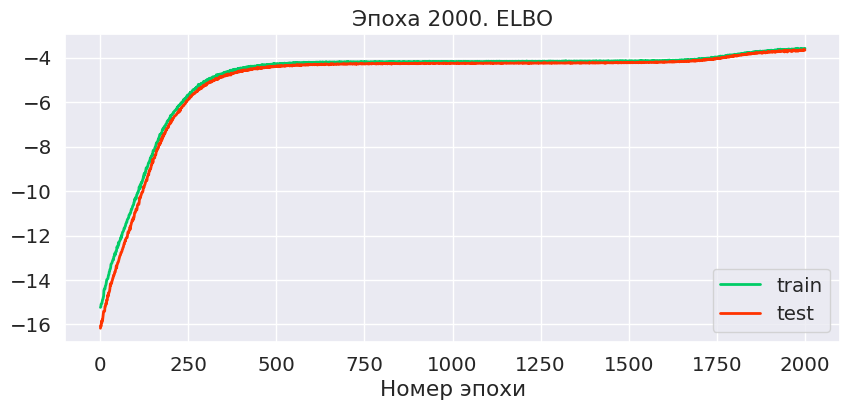

In [23]:
vaed_2d_model = VAE2D(use_cuda=USE_CUDA)
vaed_2d_model.to(DEVICE)

vaed_2d_model.fit(train_loader=train_loader, test_loader=valid_loader, epochs=2001, lr=3e-4)

Так как в прошлом дз вероятностный PCA полностью совпал с обычным на предложенных данных, то без потери общности сранение можно провести с обычным PCA.

In [25]:
def compare_pca_vae(
    vae_model,
    train_data,
    valid_data,
    train_loader,
    valid_loader,
    device="cpu",
    x_limits=None,
    y_limits=None,
):
    """
    Сравнение восстановления данных с помощью PCA и VAE,
    с ограничением масштабов осей. Графики строятся по валидационным данным,
    обучающие данные отображаются прозрачным цветом для контекста.

    Параметры:
    -----------
    vae_model : обученный экземпляр VAE2D (или VAE)
    train_data : torch.Tensor или np.ndarray
        Данные обучения (2D точки)
    valid_data : torch.Tensor или np.ndarray
        Валидационные данные (2D точки)
    train_loader : DataLoader
        DataLoader для обучающей выборки
    valid_loader : DataLoader
        DataLoader для валидационной выборки
    device : str, optional
        'cpu' или 'cuda'. По умолчанию 'cpu'.
    quantile_limits : tuple(float, float)
        Нижняя и верхняя квантили для ограничения шкалы осей (по умолчанию (0.01, 0.99)).
    """

    vae_model.eval()
    device = torch.device(device)

    # Преобразуем данные в numpy если они являются тензорами
    if hasattr(valid_data, 'numpy'):
        valid_data_np = valid_data.cpu().numpy()
    else:
        valid_data_np = valid_data
        
    if hasattr(train_data, 'numpy'):
        train_data_np = train_data.cpu().numpy()
    else:
        train_data_np = train_data

    # Получаем латентные представления VAE
    vae_values = []
    with torch.no_grad():
        for x, _ in valid_loader:
            x = x.to(device)
            y_loc, y_scale = vae_model.encoder_(x)
            z_sample = y_loc + torch.randn_like(y_scale) * y_scale
            vae_values.append(z_sample.cpu().numpy())
    vae_values = np.concatenate(vae_values, axis=0)

    # Декодируем латентные переменные обратно в пространство данных
    decoded_points = []
    with torch.no_grad():
        for z in torch.tensor(vae_values, dtype=torch.float32, device=device):
            mean_x, _ = vae_model.decoder_(z.unsqueeze(0))
            decoded_points.append(mean_x.detach().cpu().numpy().ravel())
    decoded_points = np.array(decoded_points)

    # PCA обучается на train_data, восстанавливает valid_data
    pca = PCA(n_components=1)
    pca.fit(train_data_np)
    Z_pca = (valid_data_np - pca.mean_) @ pca.components_.T
    X_recon_pca = pca.inverse_transform(Z_pca)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    if not x_limits or not y_limits:
        x_min, x_max = np.min(valid_data_np[:, 0]), np.max(valid_data_np[:, 0])
        y_min, y_max = np.min(valid_data_np[:, 1]), np.max(valid_data_np[:, 1])
        padding_x = (x_max - x_min) * 0.1
        padding_y = (y_max - y_min) * 0.1
        x_min -= padding_x
        x_max += padding_x
        y_min -= padding_y
        y_max += padding_y

    else:
        x_min, x_max = x_limits
        y_min, y_max = y_limits
        
    # PCA
    axes[0].scatter(
        train_data_np[:, 0],
        train_data_np[:, 1],
        color="lightblue",
        alpha=0.7,
        s=10,
        label="Train data",
    )
    axes[0].scatter(
        valid_data_np[:, 0], valid_data_np[:, 1], color="gray", alpha=0.8, label="Valid data"
    )
    axes[0].scatter(
        X_recon_pca[:, 0],
        X_recon_pca[:, 1],
        color="green",
        alpha=0.4,
        label="Recovered via PCA",
    )
    axes[0].set_title("Восстановленные данные PCA")
    axes[0].legend()
    axes[0].grid(True, linestyle=":", alpha=0.6)
    axes[0].axis("auto")
    axes[0].set_xlim(x_min, x_max)
    axes[0].set_ylim(y_min, y_max)

    # VAE
    axes[1].scatter(
        train_data_np[:, 0],
        train_data_np[:, 1],
        color="lightblue",
        alpha=0.3,
        s=10,
        label="Train data",
    )
    axes[1].scatter(
        valid_data_np[:, 0], valid_data_np[:, 1], color="gray", alpha=0.7, label="Valid data"
    )
    axes[1].scatter(
        decoded_points[:, 0],
        decoded_points[:, 1],
        color="red",
        alpha=0.7,
        label="Recovered via VAE",
    )
    axes[1].set_title("Восстановленные данные VAE")
    axes[1].legend()
    axes[1].grid(True, linestyle=":", alpha=0.6)
    axes[1].axis("auto")
    axes[1].set_xlim(x_min, x_max)
    axes[1].set_ylim(y_min, y_max)

    plt.tight_layout()
    plt.show()

    return {
        "vae_latent": vae_values,
        "vae_decoded": decoded_points,
        "pca_reconstructed": X_recon_pca,
        "pca_model": pca,
    }


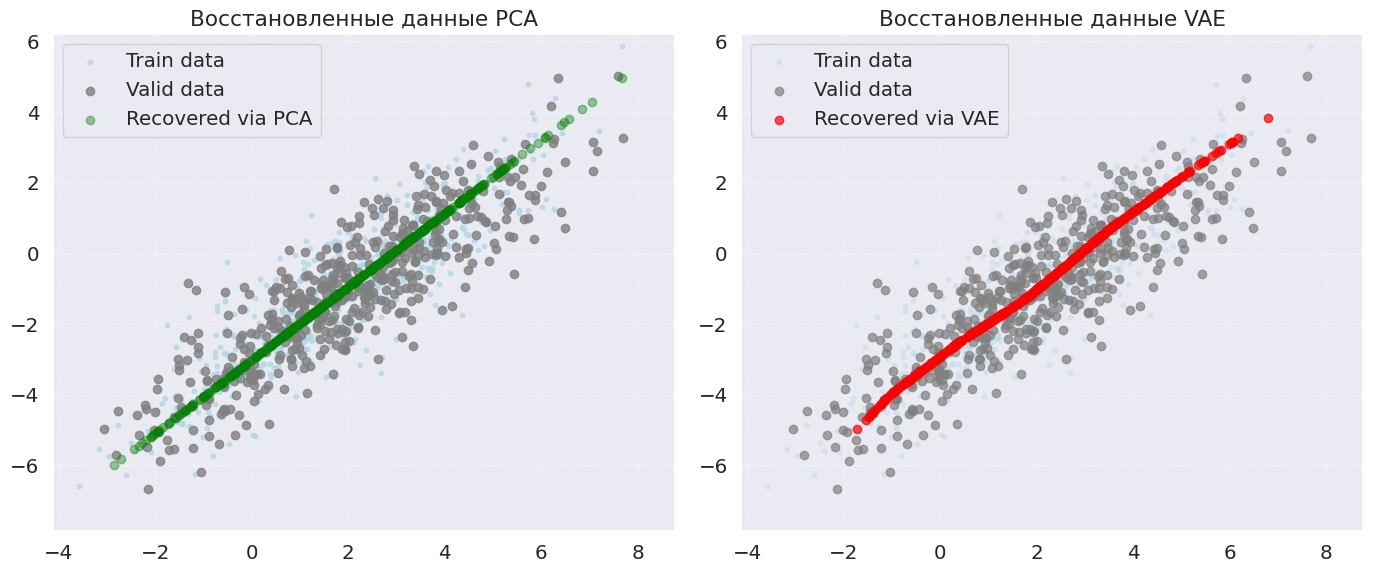

In [26]:
results = compare_pca_vae(
    vae_model=vaed_2d_model,
    train_data=train_data,
    valid_data=valid_data,
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=DEVICE
)

Как видим VAE хорошо повторяет PCA

**2.** Повторите те же действия со следующими данными.

Сразу разобьем на трейн и тест

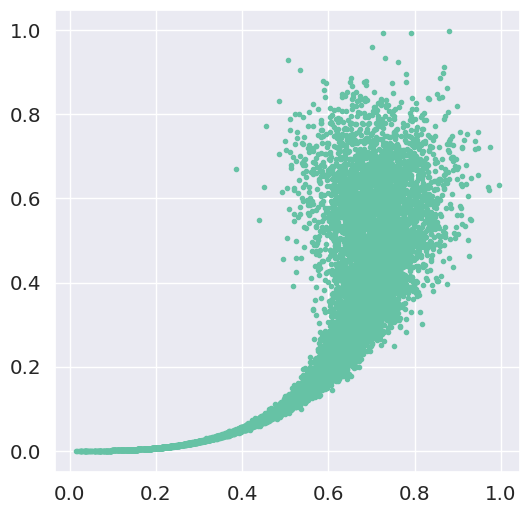

In [27]:
n = 10000

y = dist.Uniform(0, 1).rsample([n, 1])
r = torch.sqrt(y)
phi = 0.8 * y
data = torch.cat([
    r*torch.cos(phi) + dist.Normal(loc=0, scale=0.1*y**2).rsample(), 
    r*torch.sin(phi) + dist.Normal(loc=0, scale=0.1*y**2).rsample()
], 1)

train_data, valid_data = train_test_split(data, test_size=0.2)

plt.figure(figsize=(6, 6))
plt.plot(data[:,0], data[:,1], '.');

In [33]:
batch_size = 256
zeros_train = torch.zeros(len(train_data), dtype=torch.long)
zeros_valid = torch.zeros(len(valid_data), dtype=torch.long)

train_dataset = TensorDataset(train_data, zeros_train)
valid_dataset = TensorDataset(valid_data, zeros_valid)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

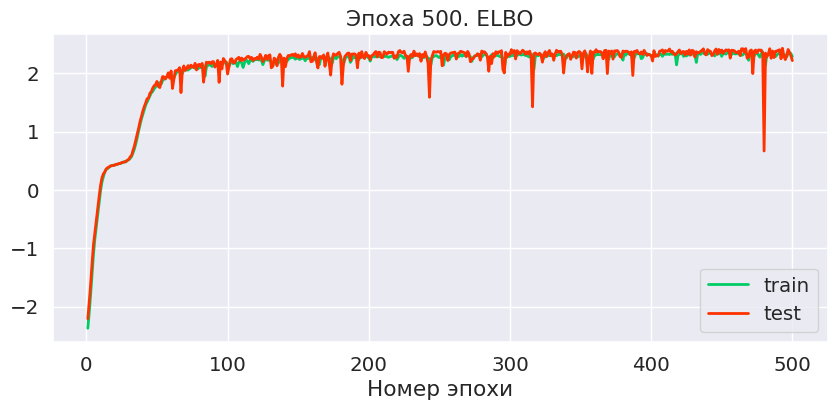

In [34]:
vaed_2d_model = VAE2D(use_cuda=USE_CUDA)
vaed_2d_model.to(DEVICE)

vaed_2d_model.fit(train_loader=train_loader, test_loader=valid_loader, epochs=501, lr=3e-4)

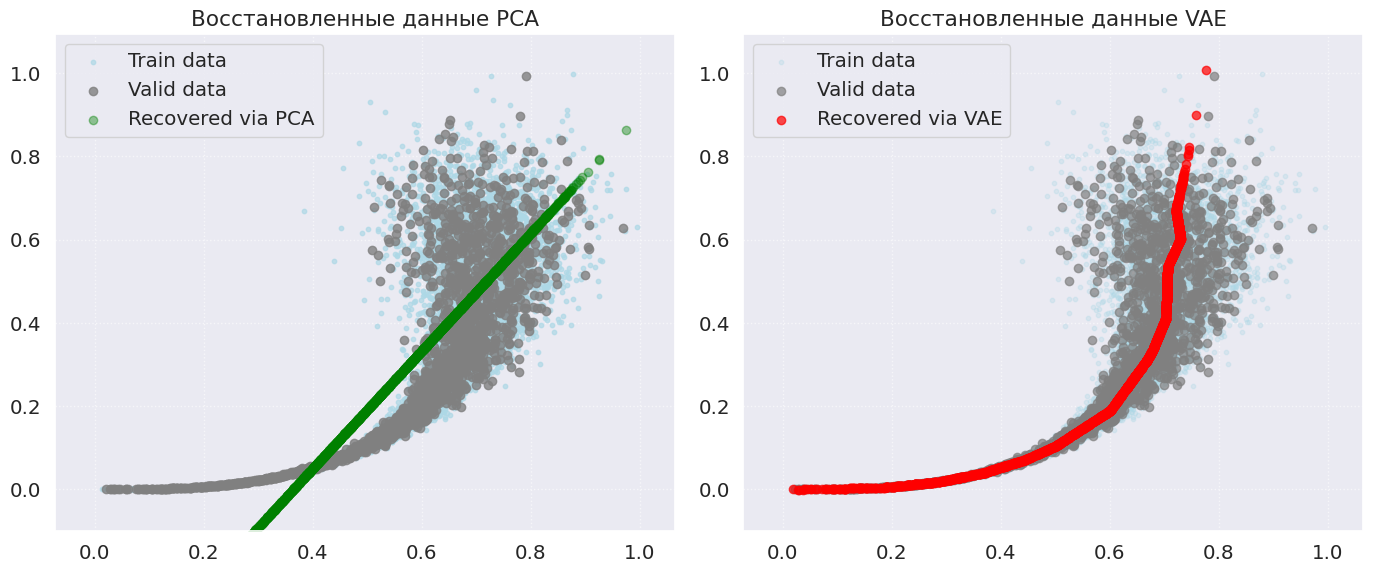

In [35]:
results = compare_pca_vae(
    vae_model=vaed_2d_model,
    train_data=train_data,
    valid_data=valid_data,
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=DEVICE
)

Как видим, VAE справился намного лучше PCA, повторив вид распределения.

**3.** Выберите 5\% случайных точек и зашумите их с помощью шума из распределения Коши, параметр масштаба распределения Коши возьмите равным 0.01. Обучите на этих данных VAE. Насколько хорошие получились результаты?

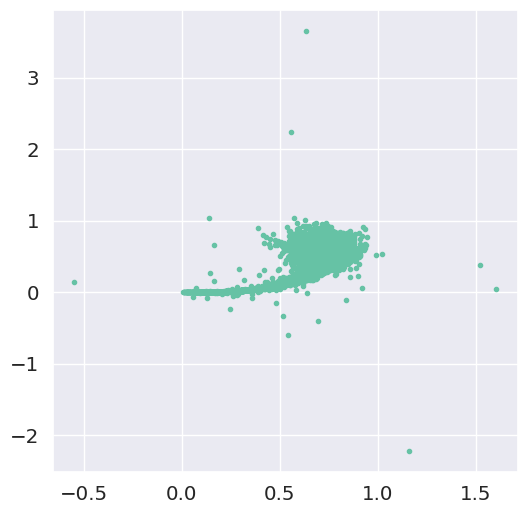

In [36]:
n = 10000

y = dist.Uniform(0, 1).rsample([n, 1])
r = torch.sqrt(y)
phi = 0.8 * y
data = torch.cat(
    [
        r * torch.cos(phi) + dist.Normal(loc=0, scale=0.1 * y**2).rsample(),
        r * torch.sin(phi) + dist.Normal(loc=0, scale=0.1 * y**2).rsample(),
    ],
    1,
)
random_indices = np.random.choice(np.arange(0, n + 1), size=int(0.05 * n), replace=False)
data[random_indices] += dist.Cauchy(loc=0, scale=0.01).rsample([len(random_indices), 2])

train_data, valid_data = train_test_split(data, test_size=0.2)

plt.figure(figsize=(6, 6))
plt.plot(data[:, 0], data[:, 1], ".")

In [37]:
batch_size = 256
zeros_train = torch.zeros(len(train_data), dtype=torch.long)
zeros_valid = torch.zeros(len(valid_data), dtype=torch.long)

train_dataset = TensorDataset(train_data, zeros_train)
valid_dataset = TensorDataset(valid_data, zeros_valid)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

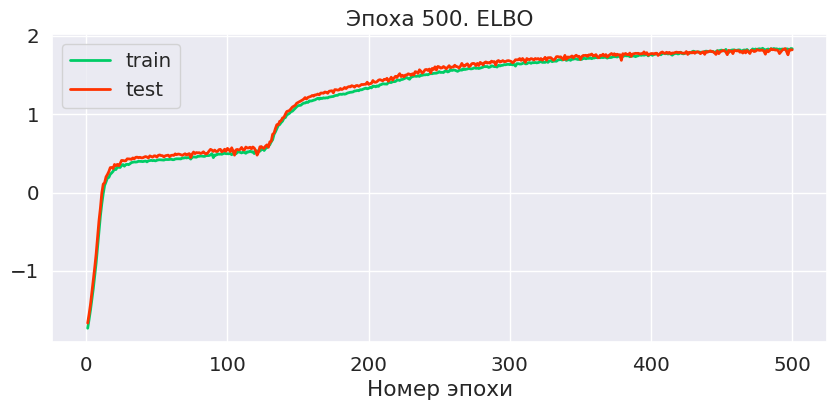

In [38]:
vaed_2d_model = VAE2D(use_cuda=USE_CUDA)
vaed_2d_model.to(DEVICE)

vaed_2d_model.fit(train_loader=train_loader, test_loader=valid_loader, epochs=501, lr=3e-4)

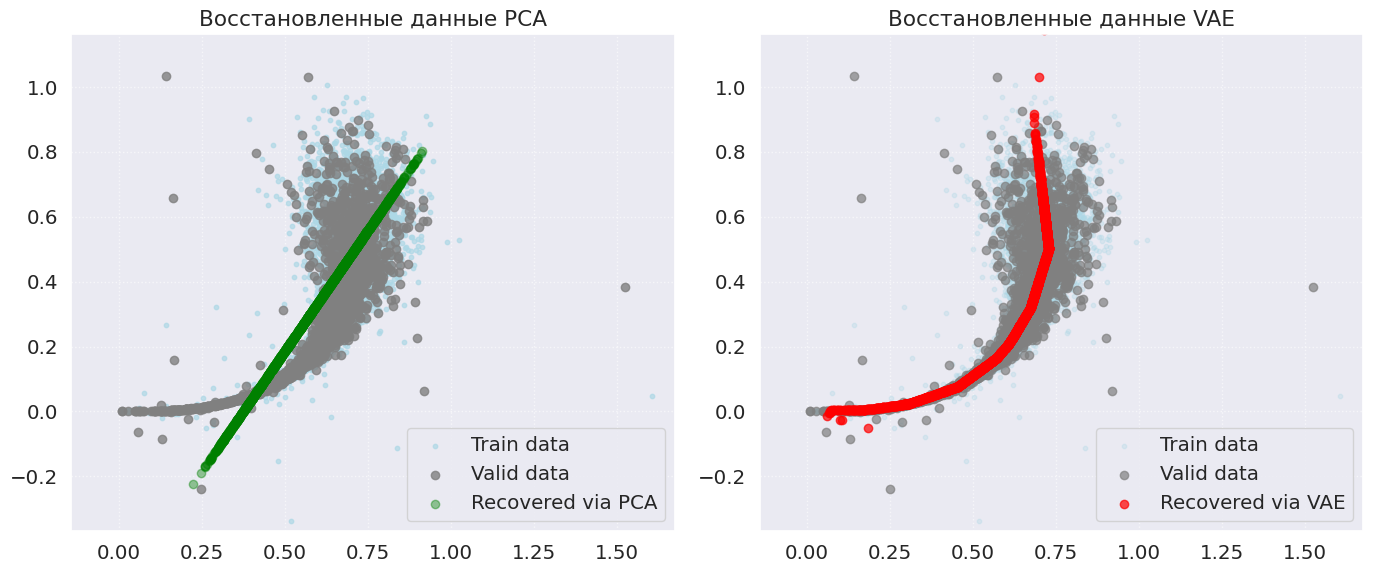

In [39]:
results = compare_pca_vae(
    vae_model=vaed_2d_model,
    train_data=train_data,
    valid_data=valid_data,
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=DEVICE
)

Как видим VAE имеет выбросы по концам.

Замените в VAE распределение данных $X$ на распределение Стьюдента, установив число степеней свободы в качестве гиперпараметра. Обучите полученную модель.

In [40]:
class VAE2DStudent(VAE):
    def __init__(self, y_dim=1, df=5, hidden_dim=16, use_cuda=False):
        super().__init__(y_dim=y_dim, p=0, use_cuda=use_cuda)
        self.encoder_ = Encoder2D(y_dim=y_dim, hidden_dim=hidden_dim)
        self.decoder_ = Decoder2D(y_dim=y_dim, hidden_dim=hidden_dim)
        self.df = df

    def model(self, x):
        if self.use_cuda:
            x = x.cuda()
        pyro.module("decoder", self.decoder_)
        with pyro.plate("data", x.shape[0]):
            y_loc = x.new_zeros((x.shape[0], self.y_dim))
            y_scale = x.new_ones((x.shape[0], self.y_dim))
            y = pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))
            loc_x, scale_x = self.decoder_(y)
            pyro.sample("obs", dist.StudentT(loc=loc_x, scale=scale_x, df=self.df).to_event(1), obs=x)

    def guide(self, x):
        if self.use_cuda:
            x = x.cuda()
        pyro.module("encoder", self.encoder_)
        with pyro.plate("data", x.shape[0]):
            y_loc, y_scale = self.encoder_(x)
            pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))

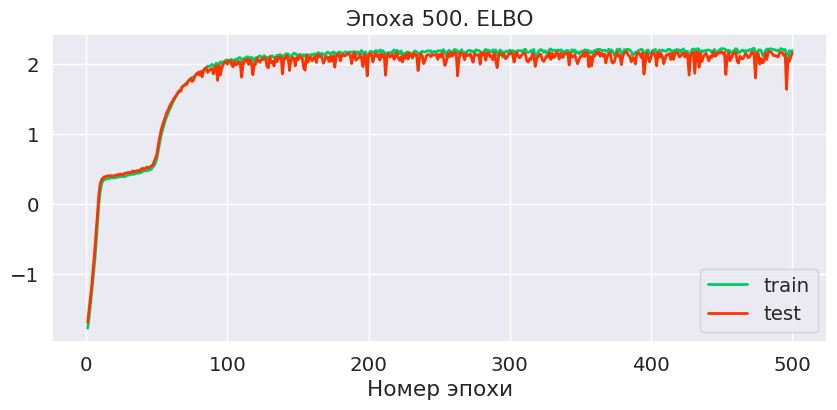

In [41]:
vaed_2d_model = VAE2DStudent(use_cuda=USE_CUDA, df=5)
vaed_2d_model.to(DEVICE)

vaed_2d_model.fit(train_loader=train_loader, test_loader=valid_loader, epochs=501, lr=3e-4)

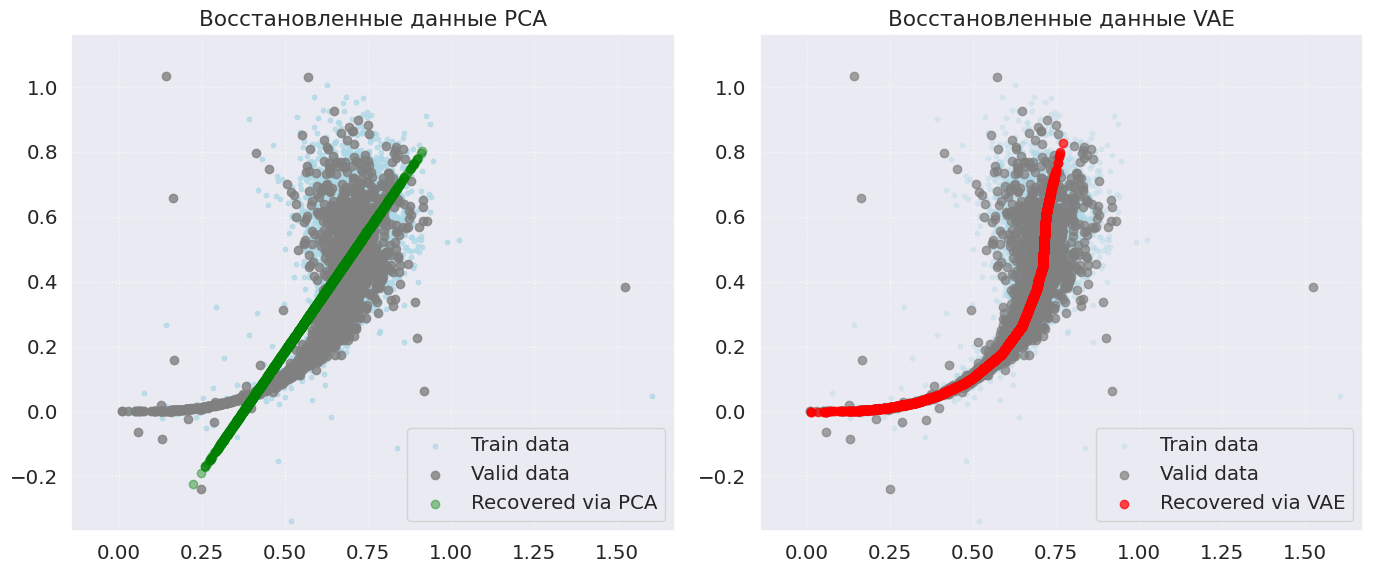

In [42]:
results = compare_pca_vae(
    vae_model=vaed_2d_model,
    train_data=train_data,
    valid_data=valid_data,
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=DEVICE
)

Замена на Стьюдента решила проблему с выбросами по концам

Сделайте выводы по задаче.

**ВЫВОДЫ:**

Мы досконально исследовали VAE.

Увидели, что VAE действительно пораждает непрерывное пространство объектов, в то время как AE достаточно дискретен. Увидели, что PCA совершенно не может восстановить исходные изображения, а причина такого стала ясна из второй части, где мы увидели, что PCA не может повторить нелинейные данные.

Так как при работе с MNIST мы не использовали распределение Стьюдента, то допускаю, что там также могли быть выбросы, по примеру того, что мы видели в конце.

---
### Задача 2.

Эта задача призвана проиллюстрировать на простом примере принцип работы условного вариационного автоэнкодера (CVAE) и сравнить его с обычным вариационным автоэнкодером (VAE).

Повторите эксперимент из задачи 1 со следующими данными:

/home/udeneev-av/tmp/ipykernel_2787294/1500095863.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  -np.exp(-x+2) + 3*x - 2


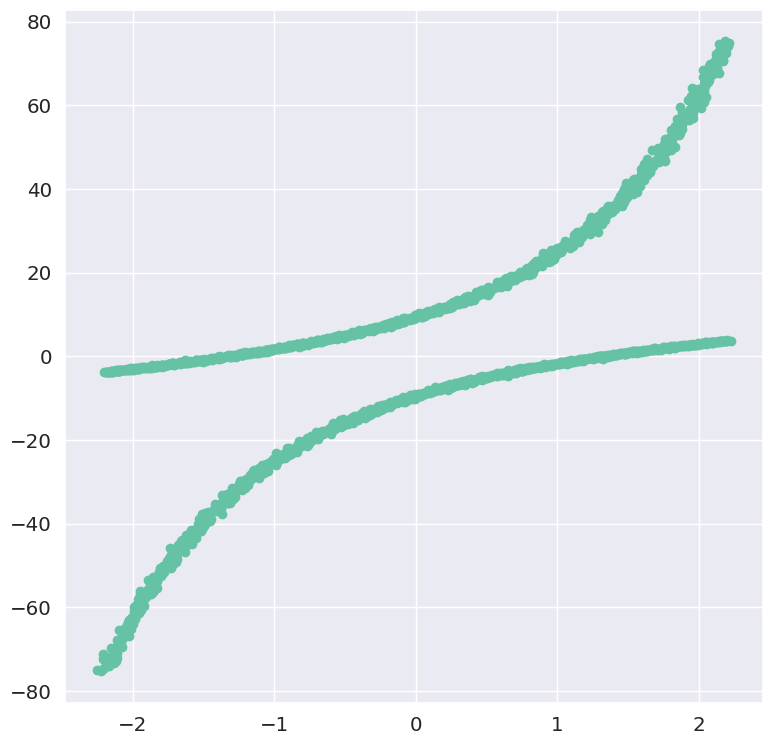

In [43]:
n = 2000

# Данные
x = torch.linspace(-2.2, 2.2, n//2).view((-1, 1))
data1 = torch.cat([
    x, 
    torch.exp(x+2) + 3*x + 2
], 1)
data2 = torch.cat([
    x, 
    -np.exp(-x+2) + 3*x - 2
], 1)

data = torch.cat([data1, data2])
labels = torch.tensor([0] * (n//2) + [1] * (n//2))
data += dist.Normal(loc=0, scale=0.03).rsample(data.shape)

# Метки
labels = torch.zeros(n).view((-1, 1))
labels[n//2:] = 1

# Визуализация
plt.figure(figsize=(9, 9))
plt.scatter(data[:, 0], data[:, 1]);

In [44]:
train_data, valid_data = train_test_split(data, test_size=0.2)
batch_size = 128
zeros_train = torch.zeros(len(train_data), dtype=torch.long)
zeros_valid = torch.zeros(len(valid_data), dtype=torch.long)

train_dataset = TensorDataset(train_data, zeros_train)
valid_dataset = TensorDataset(valid_data, zeros_valid)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

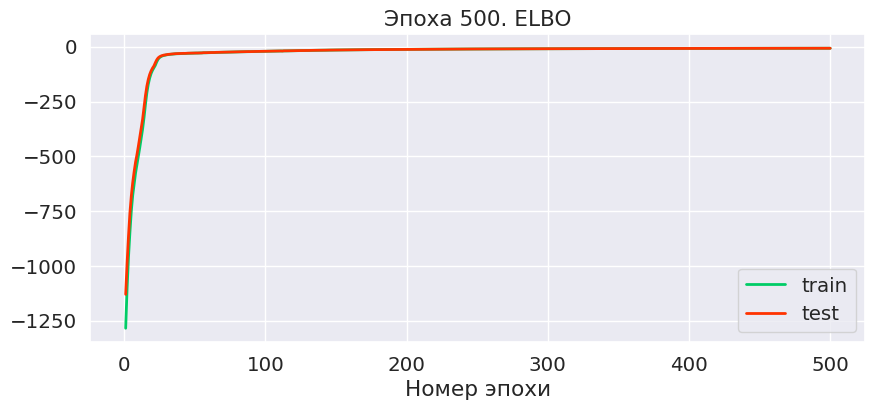

In [ ]:
vaed_2d_model = VAE2D(use_cuda=USE_CUDA)
vaed_2d_model.to(DEVICE)

vaed_2d_model.fit(train_loader=train_loader, test_loader=valid_loader, epochs=2001, lr=5e-4)

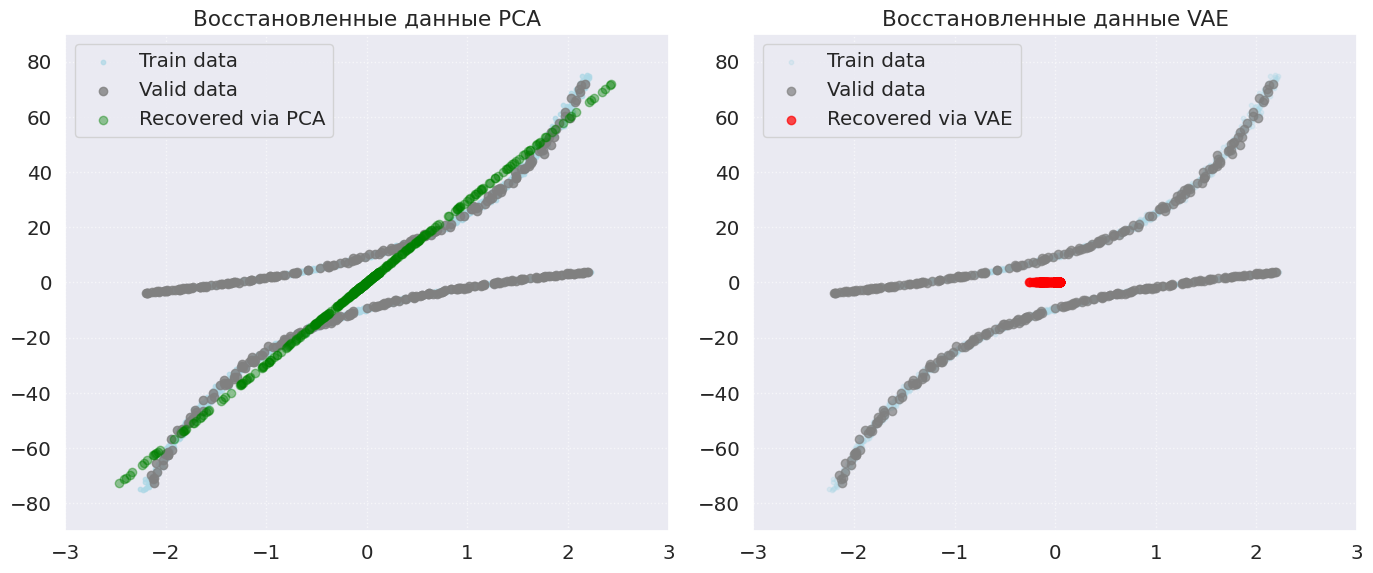

In [46]:
results = compare_pca_vae(
    vae_model=vaed_2d_model,
    train_data=train_data,
    valid_data=valid_data,
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=DEVICE,
    x_limits=(-3, 3),
    y_limits=(-90, 90)
)

Как видим, обе модели не справились.

Теперь обучите на этих данных CVAE, передавая в качестве метки номер кривой. Проинтерпретируйте результаты.

In [50]:
class Encoder2D(nn.Module):
    def __init__(self, y_dim=1, label_dim=0, hidden_dim=16):
        super().__init__()
        input_dim = 2 + label_dim if label_dim > 0 else 2
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mean = nn.Linear(hidden_dim, y_dim)
        self.fc_logvar = nn.Linear(hidden_dim, y_dim)

    def forward(self, x, labels=None):
        if labels is not None:
            x = torch.cat([x, labels], dim=1)
        h = self.net(x)
        mu = self.fc_mean(h)
        scale = F.softplus(self.fc_logvar(h)) + 1e-6
        return mu, scale


class Decoder2D(nn.Module):
    def __init__(self, y_dim=1, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(y_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, z):
        mean = self.net(z)
        scale = torch.ones_like(mean) * 0.1
        return mean, scale


# Базовый VAE2D — можно унаследовать от nn.Module (убери автоперенос на cuda в __init__)
class VAE2D(nn.Module):
    def __init__(self, y_dim=1, hidden_dim=16, use_cuda=False):
        super().__init__()
        self.encoder_ = Encoder2D(y_dim=y_dim, hidden_dim=hidden_dim)
        self.decoder_ = Decoder2D(y_dim=y_dim, hidden_dim=hidden_dim)
        self.use_cuda = use_cuda
        self.y_dim = y_dim


class CVAE(VAE2D):
    def __init__(self, y_dim=1, label_dim=1, hidden_dim=16, use_cuda=False):
        super().__init__(y_dim, hidden_dim, use_cuda)
        self.label_dim = label_dim
        self.encoder_ = Encoder2D(
            y_dim=y_dim, label_dim=label_dim, hidden_dim=hidden_dim
        )
        self.decoder_ = Decoder2D(y_dim=y_dim + label_dim, hidden_dim=hidden_dim)

    def model(self, x, labels):
        if self.use_cuda:
            x = x.cuda()
            labels = labels.cuda()
        pyro.module("decoder", self.decoder_)
        with pyro.plate("data", x.shape[0]):
            y_loc = x.new_zeros((x.shape[0], self.y_dim))
            y_scale = x.new_ones((x.shape[0], self.y_dim))
            y = pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))

            labels_ = (
                labels.squeeze(-1)
                if labels.ndim > 1 and labels.shape[1] == 1
                else labels
            )
            labels_onehot = nn.functional.one_hot(
                labels_.long(), num_classes=self.label_dim
            ).float()

            latent_input = torch.cat([y, labels_onehot], dim=1)
            loc_x, scale_x = self.decoder_(latent_input)
            pyro.sample("obs", dist.Normal(loc_x, scale_x).to_event(1), obs=x)

    def guide(self, x, labels):
        if self.use_cuda:
            x = x.cuda()
            labels = labels.cuda()
        pyro.module("encoder", self.encoder_)
        with pyro.plate("data", x.shape[0]):
            labels_ = (
                labels.squeeze(-1)
                if labels.ndim > 1 and labels.shape[1] == 1
                else labels
            )
            labels_onehot = nn.functional.one_hot(
                labels_.long(), num_classes=self.label_dim
            ).float()
            y_loc, y_scale = self.encoder_(x, labels_onehot)
            pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))

    def train_epoch(self, train_loader):
        epoch_loss = 0.0
        for x, labels in train_loader:
            if self.use_cuda:
                x = x.cuda(non_blocking=True)
                labels = labels.cuda(non_blocking=True)
            epoch_loss += self.svi.step(x, labels)
        return epoch_loss / len(train_loader.dataset)

    def evaluate_epoch(self, test_loader):
        test_loss = 0.0
        for x, labels in test_loader:
            if self.use_cuda:
                x = x.cuda(non_blocking=True)
                labels = labels.cuda(non_blocking=True)
            test_loss += self.svi.evaluate_loss(x, labels)
        return test_loss / len(test_loader.dataset)

    def fit(
        self,
        train_loader,
        valid_loader=None,
        epochs=50,
        lr=1e-3,
    ):
        train_losses = []
        valid_losses = []
        best_valid_loss = float("inf")
        patience_counter = 0
        pyro.clear_param_store()
        self.init_svi(lr=lr)

        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch(train_loader)
            train_losses.append(-train_loss)
            if valid_loader is not None:
                valid_loss = self.evaluate_epoch(valid_loader)
                valid_losses.append(-valid_loss)
                if visualize_or_not(epoch, epochs + 1):
                    callback(
                        train_elbo=train_losses,
                        test_elbo=valid_losses,
                        test_epoch_num=range(1, len(valid_losses)+1),
                        epoch=epoch,
                    )
        result = {"train_loss": train_losses}
        if valid_loader is not None:
            result["valid_loss"] = valid_losses
        return result

    def init_svi(self, lr=1e-3):
        optimizer = Adam({"lr": lr})
        elbo = Trace_ELBO()
        self.svi = SVI(self.model, self.guide, optimizer, loss=elbo)

In [51]:
train_data, valid_data, train_labels, valid_labels = train_test_split(
    data, labels, test_size=0.2, random_state=42, shuffle=True
)

train_dataset = TensorDataset(train_data, train_labels)
valid_dataset = TensorDataset(valid_data, valid_labels)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False)

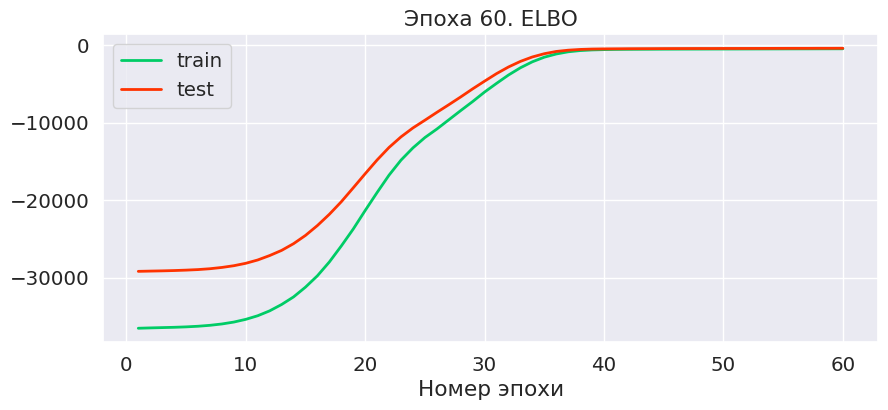

KeyboardInterrupt: 

In [ ]:
cvae_model = CVAE(use_cuda=USE_CUDA, label_dim=2)
cvae_model.to(DEVICE)

cvae_model.fit(train_loader=train_loader, valid_loader=valid_loader, epochs=2001, lr=5e-4);

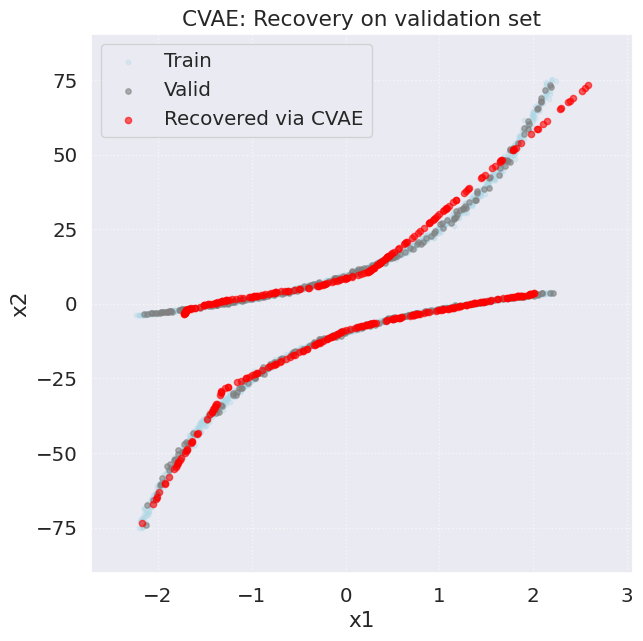

In [ ]:
cvae_model.eval()
vae_values = []
all_valid_labels = []
with torch.no_grad():
    for x_batch, labels_batch in valid_loader:
        x_batch = x_batch.to(DEVICE)
        labels_batch = labels_batch.to(DEVICE)
        labels_oh = torch.nn.functional.one_hot(
            labels_batch.squeeze(-1).long(), num_classes=cvae_model.label_dim
        ).float()
        y_loc, y_scale = cvae_model.encoder_(x_batch, labels_oh)
        z_sample = y_loc + torch.randn_like(y_scale) * y_scale
        vae_values.append(z_sample.cpu().numpy())
        all_valid_labels.append(labels_oh.cpu().numpy())
vae_values = np.concatenate(vae_values, axis=0)
all_valid_labels = np.concatenate(all_valid_labels, axis=0)

decoded_points = []
with torch.no_grad():
    for z, label_oh in zip(
            torch.tensor(vae_values, dtype=torch.float32, device=DEVICE),
            torch.tensor(all_valid_labels, dtype=torch.float32, device=DEVICE),
    ):
        inp = torch.cat([z.unsqueeze(0), label_oh.unsqueeze(0)], dim=1)
        mean_x, _ = cvae_model.decoder_(inp)
        decoded_points.append(mean_x.detach().cpu().numpy().ravel())
decoded_points = np.array(decoded_points)

all_points = np.vstack([train_data, valid_data, decoded_points])
x_min, x_max = np.min(all_points[:, 0]), np.max(all_points[:, 0])
y_min, y_max = np.min(all_points[:, 1]), np.max(all_points[:, 1])
pad_x = 0.1 * (x_max - x_min)
pad_y = 0.1 * (y_max - y_min)
x_min -= pad_x
x_max += pad_x
y_min -= pad_y
y_max += pad_y

plt.figure(figsize=(7,7))
plt.scatter(train_data[:,0], train_data[:,1], color="lightblue", label="Train", alpha=0.3, s=10)
plt.scatter(valid_data[:,0], valid_data[:,1], color="gray", label="Valid", alpha=0.6, s=15)
plt.scatter(decoded_points[:,0], decoded_points[:,1], color="red", label="Recovered via CVAE", alpha=0.6, s=20)
plt.legend()
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("CVAE: Recovery on validation set")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()


**ВЫВОДЫ:**

Как видим, дополнительная информация о номере смеси позволила модель крайней лучше кодировать и декодировать данные.

---
### Задача 3. 

Использовать готовые инструменты это хорошо, но не всегда возможно в силу различных технических ограничений, как связанными с техническими требованиями заказчика, так и возможностями самих инструментов.

Предлагаем вам потренироваться в реализации чистого VAE с помощью чистого `pytorch` без использования `pyro`. Для этого вы можете взять заготовки нейросетей с занятия и реализовать процесс обучения, оптимизируя ELBO с помощью двойной стохастичности, что мы расписали на занятии.

Примените вашу реализацию к датасету Fashion MNIST подобно тому, как мы делали на занятии. Сравните ее с реализацией через `pyro` по следующим характеристикам:
* скорость сходимости;
* время работы;
* трудоемкость при реализации.

Насколько было бы просто обходиться без `pyro` в случае более сложных распределений и зависимостей?

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока

In [6]:
def get_fashion_MNIST(batch_size=128, use_cuda=False):
    root = './data'
    download = True
    trans = transforms.ToTensor()
    
    train_set = dset.FashionMNIST(
        root=root, train=True, transform=trans, download=download
    )
    test_set = dset.FashionMNIST(
        root=root, train=False, transform=trans
    )

    kwargs = {'num_workers': 20, 'pin_memory': use_cuda}
    
    train_loader = torch.utils.data.DataLoader(
        dataset=train_set, batch_size=batch_size, shuffle=True, **kwargs
    )
    test_loader = torch.utils.data.DataLoader(
        dataset=test_set, batch_size=batch_size, shuffle=True, **kwargs
    )
    
    return train_loader, test_loader

train_loader, valid_loader = get_fashion_MNIST(batch_size=2048, use_cuda=USE_CUDA)

In [7]:
class Encoder(nn.Module):

    def __init__(self, y_dim, p=0.1):
        super(Encoder, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(p),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(p),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(p),
        )

        self.fc_mean = nn.Linear(128, y_dim)
        self.fc_logvar = nn.Linear(128, y_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.net(x)
        y_loc = self.fc_mean(h)
        y_scale = F.softplus(self.fc_logvar(h)) + 1e-6
        return y_loc, y_scale


class Decoder(nn.Module):
    def __init__(self, y_dim, p=0.1):
        super(Decoder, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(y_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(p),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(p),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(p),
        )

        self.fc_mean = nn.Linear(512, 28 * 28)
        self.fc_logvar = nn.Linear(512, 28 * 28)

    def forward(self, y):
        h = self.net(y)
        mean = torch.sigmoid(self.fc_mean(h))
        logvar = self.fc_logvar(h)

        scale = F.softplus(logvar).view(-1, 1, 28, 28) + 1e-6
        mean = mean.view(-1, 1, 28, 28)

        return mean, scale

In [ ]:
class MyVAE(nn.Module):
    def __init__(self, y_dim=2, p=0.2, use_cuda=False):
        super().__init__()

        # Объявляем энкодер и декодер
        self.encoder_ = Encoder(y_dim, p)
        self.decoder_ = Decoder(y_dim, p)

        self.use_cuda = use_cuda
        self.y_dim = y_dim
        
    def E_step(self, x):
        y_loc, y_scale = self.encoder_(x)
        eps = torch.randn_like(y_scale)
        y = y_loc + y_scale * eps
        return y, y_loc, y_scale
    
    def M_step(self, y):
        x_loc, x_scale = self.decoder_(y)
        return x_loc, x_scale
    
    def ELBO(self, x, y_loc, y_scale, x_loc, x_scale):
        first_item = torch.sum(torch.distributions.Normal(x_loc, x_scale).log_prob(x), dim=1).mean()
        
        q_y_given_x = torch.distributions.Normal(y_loc, y_scale)
        p_y = torch.distributions.Normal(torch.zeros_like(y_loc), torch.ones_like(y_scale))
        second_item = torch.distributions.kl_divergence(q_y_given_x, p_y).sum(dim=1).mean()
        
        elbo = first_item - second_item
        return -elbo

    
    def forward(self, x):
        y, y_loc, y_scale = self.E_step(x)
        x_loc, x_scale = self.M_step(y)
        return x_loc, x_scale, y_loc, y_scale
    
    def train_epoch(self, train_loader, optimizer):
        self.train()
        epoch_loss = 0.0
        num_samples = 0
        
        for x, _ in train_loader:
            if self.use_cuda:
                x = x.cuda(non_blocking=True)
            
            optimizer.zero_grad()
            x_loc, x_scale, y_loc, y_scale = self.forward(x)
            loss = self.ELBO(x, y_loc, y_scale, x_loc, x_scale)
            
            loss.backward()
            optimizer.step()
            
            batch_size = x.size(0)
            epoch_loss += loss.item() * batch_size
            num_samples += batch_size
    
        return epoch_loss / num_samples
    
    def evaluate_epoch(self, test_loader):
        self.eval()
        test_loss = 0.0
        num_samples = 0
        
        with torch.no_grad():
            for x, _ in test_loader:
                if self.use_cuda:
                    x = x.cuda(non_blocking=True)
                
                x_loc, x_scale, y_loc, y_scale = self.forward(x)
                loss = self.ELBO(x, y_loc, y_scale, x_loc, x_scale)
                batch_size = x.size(0)
                test_loss += loss.item() * batch_size
                num_samples += batch_size
        
        return test_loss / num_samples

    def fit(self, train_loader, valid_loader=None, epochs=100, lr=1e-3):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)            
        train_losses = []
        test_losses = []
        test_epoch_num = []
        
        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader, optimizer)
            train_losses.append(-train_loss)

            if valid_loader is not None:
                test_loss = self.evaluate_epoch(valid_loader)
                test_losses.append(-test_loss)
                test_epoch_num.append(epoch)

            if visualize_or_not(epoch, epochs) and valid_loader is not None:
                callback(train_losses, test_losses, test_epoch_num, epoch, title="ELBO")
        
        return train_losses, test_losses
    
    def reconstruct_img(self, x, return_cpu=True):
        if self.use_cuda:
            x = x.cuda()

        y_loc, _ = self.encoder_(x)
        loc_img = self.decoder_(y_loc)

        if self.use_cuda and return_cpu:
            loc_img = loc_img.cpu()
        return loc_img
    def encoder(self, x, return_cpu=True):
        """Обертка над энкодером, выполняющая работу по переводу тензоров между CPU и GPU"""

        if self.use_cuda:
            x = x.cuda()

        y_loc, y_scale = self.encoder_(x)

        if self.use_cuda and return_cpu:
            y_loc = y_loc.cpu()
            y_scale = y_scale.cpu()
        return y_loc, y_scale

    def decoder(self, y, return_cpu=True):
        """Обертка над декодером, выполняющая работу по переводу тензоров между CPU и GPU"""

        if self.use_cuda:
            y = y.cuda()

        loc_img, scale_img = self.decoder_(y)

        if self.use_cuda and return_cpu:
            loc_img = loc_img.cpu()
            scale_img = scale_img.cpu()
        return loc_img, scale_img

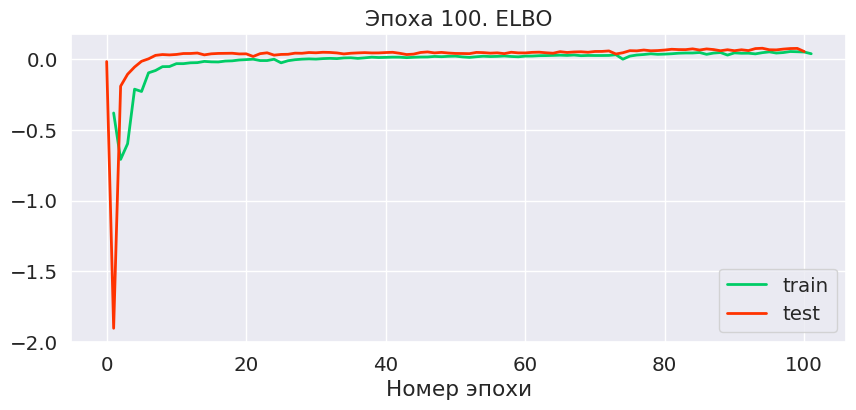

In [9]:
my_vae_model = MyVAE(use_cuda=USE_CUDA)
my_vae_model.to(DEVICE)

my_vae_model.fit(train_loader=train_loader, valid_loader=valid_loader, epochs=101, lr=1e-3);

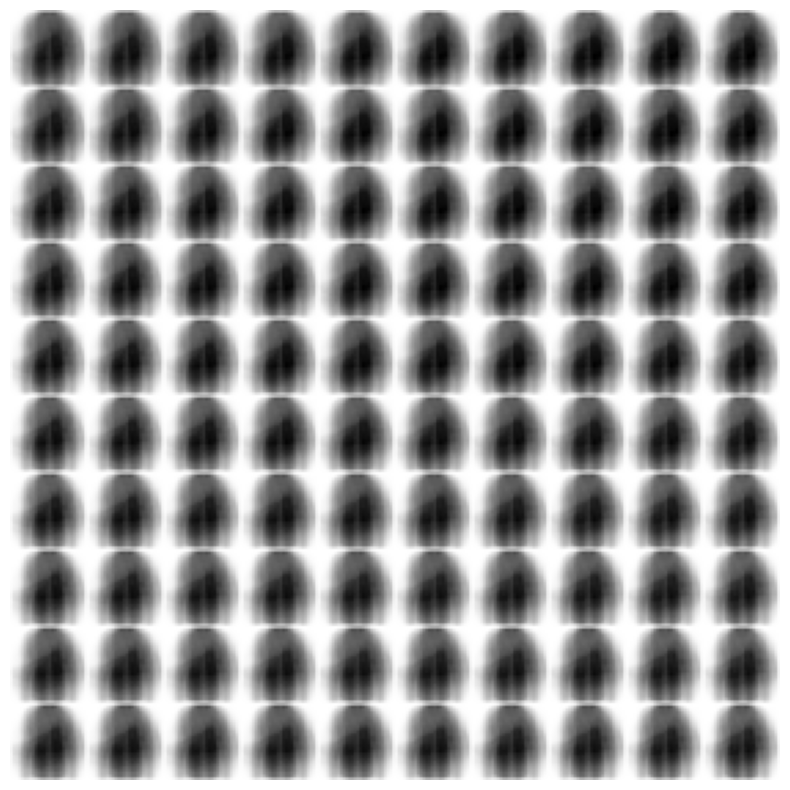

In [ ]:
X1 = np.linspace(-10, 10, 10)
X2 = np.linspace(-10, 10, 10)
figure = np.zeros((28 * len(X1), 28 * len(X2)))
my_vae_model.eval()

with torch.no_grad():
    for i, x1 in enumerate(X1):
        for j, x2 in enumerate(X2):
            z = torch.tensor([[x1, x2]], dtype=torch.float32).to(DEVICE)
            img, _ = my_vae_model.decoder_(z)
            digit = np.clip(img[0, 0].detach().cpu().numpy(), 0, 1)
            figure[
                (len(X1) - 1 - i) * 28 : (len(X1) - i) * 28, j * 28 : (j + 1) * 28
            ] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray_r")
plt.axis("off")
plt.show()

In [ ]:
sample = np.random.multivariate_normal(mean = (0, 0), cov = np.eye(2), size=1000)

In [ ]:
create_data_image(my_vae_model, sample=sample, max_pictures=300, figsize=(30, 30), zoom=1, axis=True)